# Dissertation Suryer data Analysis
* RQ1 How does visualising the underlying values affect users’ perceptions of the chatbots?
* RQ2 How do different value visualisation approaches influence users’ perceived trust, autonomy, competence, feeling informed and value alignment
* RQ3 How does co-design compare with standard charts?

 - Chatbot A = Non-visualisation
 - Chatbot B = Bar chart condition
  - Chatbot C = Radar Chart Condition
  - Chatbot D = Customer Chart Condition

### Step 1: Import Libraries
- This step imports the required libraries for data handling, reliability diagnostics, non-parametric testing, robustness checks, multiple-comparison correction, and visualisation.

In [34]:
import pandas as pd
import re
import numpy as np
import pingouin as pg
from scipy import stats
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully!")

All libraries loaded successfully!


### Step 1.5: Define Helper Functions

Centralised helper functions were defined for consistent statistical reporting. These functions format p-values, interpret Cohen’s dz, calculate descriptive statistics, compute paired mean-difference confidence intervals, run paired comparison summaries, apply Holm correction, and calculate reliability diagnostics including Cronbach’s Alpha, McDonald’s Omega, and corrected item-total correlations.

Defining these functions in one location ensures consistency across all analyses and reduces code duplication. Each function references the relevant methodological literature in its docstring.

In [35]:
def format_p_text(p, label="p"):
    """
    Format p-values for text reporting.
    """
    if pd.isna(p):
        return "NA"
    
    if p < 0.001:
        return f"{label} < .001"
    
    formatted = f"{p:.3f}".replace("0.", ".")
    return f"{label} = {formatted}"


def format_p_cell(p):
    """
    Format p-values for table cells where the column name already
    states whether the value is raw or adjusted.
    """
    if pd.isna(p):
        return "NA"
    
    if p < 0.001:
        return "< .001"
    
    return f"{p:.3f}".replace("0.", ".")


def interpret_significance(p, alpha=0.05):
    """
    Determine whether a p-value is statistically significant at a given alpha level.
    """
    if pd.isna(p):
        return "NA"
    return "Yes" if p < alpha else "No"


def interpret_cohens_dz(dz):
    """
    Interpret Cohen's dz magnitude using Cohen's conventional thresholds
    and Sawilowsky's extended threshold for very large effects.

    These labels are used as descriptive heuristics.
    """
    if pd.isna(dz):
        return "NA"
    
    abs_dz = abs(dz)
    
    if abs_dz >= 1.2:
        return "Very large"
    elif abs_dz >= 0.8:
        return "Large"
    elif abs_dz >= 0.5:
        return "Medium"
    elif abs_dz >= 0.2:
        return "Small"
    else:
        return "Very small"


def interpret_cronbach_alpha(alpha):
    """
    Interpret Cronbach's Alpha using common descriptive thresholds.
    These thresholds are treated as guidance, not fixed rules.
    """
    if pd.isna(alpha):
        return "NA"
    elif alpha >= 0.90:
        return "Excellent"
    elif alpha >= 0.80:
        return "Good"
    elif alpha >= 0.70:
        return "Acceptable"
    elif alpha >= 0.60:
        return "Questionable"
    elif alpha >= 0.50:
        return "Poor"
    else:
        return "Unacceptable"


def mean_sd(series):
    """
    Format mean and standard deviation.
    """
    series = pd.Series(series).dropna().astype(float)
    return f"{series.mean():.2f} ({series.std(ddof=1):.2f})"


def median_iqr(series):
    """
    Format median and interquartile range.
    """
    series = pd.Series(series).dropna().astype(float)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{series.median():.2f} ({q1:.2f}-{q3:.2f})"


def paired_mean_diff_ci(diff, confidence=0.95):
    """
    Calculate mean paired difference and 95% confidence interval.
    The confidence interval is reported descriptively alongside
    Wilcoxon signed-rank tests.
    """
    diff = pd.Series(diff).dropna().astype(float)
    n = len(diff)
    
    mean_diff = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    
    ci_low = mean_diff - t_crit * se
    ci_high = mean_diff + t_crit * se
    
    return mean_diff, ci_low, ci_high


def paired_comparison_summary(
    wide_df,
    condition_1_col,
    condition_2_col,
    outcome_name,
    comparison_label
):
    """
    Create a paired comparison summary.
    Primary inferential test:Wilcoxon signed-rank test.
    Robustness check: Paired-samples t-test.
    Difference direction: condition_1_col - condition_2_col.
    """
    condition_1 = wide_df[condition_1_col].astype(float)
    condition_2 = wide_df[condition_2_col].astype(float)
    diff = condition_1 - condition_2

    # Primary non-parametric test
    w_stat, p_wilcoxon = wilcoxon(
        condition_1,
        condition_2,
        alternative="two-sided"
    )

    # Parametric robustness check
    t_stat, p_ttest = ttest_rel(condition_1, condition_2)

    # Mean paired difference and CI
    mean_diff, ci_low, ci_high = paired_mean_diff_ci(diff)

    # Cohen's dz
    dz = mean_diff / diff.std(ddof=1)

    return {
        "Outcome": outcome_name,
        "Comparison": comparison_label,
        "Condition 1 M (SD)": mean_sd(condition_1),
        "Condition 2 M (SD)": mean_sd(condition_2),
        "Condition 1 Median (IQR)": median_iqr(condition_1),
        "Condition 2 Median (IQR)": median_iqr(condition_2),
        "Mean Paired Difference": round(mean_diff, 3),
        "95% CI for Mean Difference": f"[{ci_low:.3f}, {ci_high:.3f}]",
        "Wilcoxon W": round(w_stat, 3),
        "p_raw_numeric": p_wilcoxon,
        "p (Wilcoxon raw)": format_p_cell(p_wilcoxon),
        "t (df=29)": round(t_stat, 3),
        "p (t-test robustness)": format_p_cell(p_ttest),
        "Cohen's dz": round(dz, 3),
        "Effect Size": interpret_cohens_dz(dz)
    }


def apply_holm_correction(df, p_col="p_raw_numeric"):
    """
    Apply Holm correction to a defined family of tests.
    """
    df = df.copy()
    
    reject, p_corrected, _, _ = multipletests(
        df[p_col].values,
        alpha=0.05,
        method="holm"
    )
    
    df["p_holm_numeric"] = p_corrected
    df["Holm-adjusted p"] = df["p_holm_numeric"].apply(format_p_cell)
    df["Significant after Holm"] = df["p_holm_numeric"].apply(interpret_significance)
    
    return df


def corrected_item_total_correlations(items_df):
    """
    Calculate corrected item-total correlations.
    Each item is correlated with the sum of the remaining items.
    """
    data = items_df.dropna().astype(float)
    results = []

    for item in data.columns:
        total_without_item = data.drop(columns=[item]).sum(axis=1)
        corr = data[item].corr(total_without_item)
        results.append({
            "Item": item,
            "Corrected Item-Total Correlation": round(corr, 3)
        })

    return pd.DataFrame(results)


def mcdonalds_omega_total(items_df):
    """
    Approximate McDonald's Omega total using a one-factor model.
    Items are standardised before factor analysis.
    """
    data = items_df.dropna().astype(float)

    if data.shape[1] < 2:
        return np.nan

    try:
        X = StandardScaler().fit_transform(data)

        fa = FactorAnalysis(n_components=1, random_state=42)
        fa.fit(X)

        loadings = fa.components_.T[:, 0]
        uniquenesses = fa.noise_variance_

        # Align factor direction
        if np.sum(loadings) < 0:
            loadings = -loadings

        omega = (np.sum(loadings) ** 2) / (
            (np.sum(loadings) ** 2) + np.sum(uniquenesses)
        )

        return omega

    except Exception:
        return np.nan


def reliability_diagnostics(scale_name, items, df):
    """
    Produce reliability diagnostics for a multi-item scale:
    Cronbach's Alpha, Alpha 95% CI, McDonald's Omega,
    and corrected item-total correlations.
    """
    data = df[items].dropna().astype(float)

    alpha, ci = pg.cronbach_alpha(data=data)
    omega = mcdonalds_omega_total(data)
    item_total_df = corrected_item_total_correlations(data)

    return {
        "Scale": scale_name,
        "Items": len(items),
        "Cronbach's Alpha": round(alpha, 3),
        "Alpha 95% CI": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
        "McDonald's Omega": round(omega, 3),
        "Item-total min": round(
            item_total_df["Corrected Item-Total Correlation"].min(), 3
        ),
        "Item-total max": round(
            item_total_df["Corrected Item-Total Correlation"].max(), 3
        ),
        "Alpha Interpretation": interpret_cronbach_alpha(alpha),
        "Item-total table": item_total_df
    }


print("Helper functions loaded successfully!")

Helper functions loaded successfully!


### Step 2: Load Dataset and Inspect Structure

- This step loads the main questionnaire dataset and inspects its basic structure: number of rows, number of columns, number of participants, condition labels, and a preview of the first five rows.

- The dataset contains responses from 30 participants who each experienced four conditions (Chatbot A, B, C, D), giving 120 rows in total. Each row corresponds to one participant-condition combination and includes their item-level responses (Q1-Q22) and their condition assignment.

In [36]:
user_surveys_df = pd.read_excel(
    "dissertation_collected_dataset.xlsx",
    sheet_name=0
)

print(f"Dataset shape: {user_surveys_df.shape[0]} rows x {user_surveys_df.shape[1]} columns")
print(f"Number of participants: {user_surveys_df['Participant_ID'].nunique()}")
print(f"Original condition labels: {user_surveys_df['Condition'].unique()}")

print("\nColumn names:")
print(list(user_surveys_df.columns))

user_surveys_df.head()

Dataset shape: 120 rows x 33 columns
Number of participants: 30
Original condition labels: <StringArray>
['Chatbot_A', 'Chatbot_B', 'Chatbot_C', 'Chatbot_D']
Length: 4, dtype: str

Column names:
['Participant_ID', 'Condition', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q7_r', 'Q8_r', 'Q9_r', 'Q10_r', 'Q11_r', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q21e', 'Q22']


,Participant_ID,Condition,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q17,Q18,Q19,Q20,Q21a,Q21b,Q21c,Q21d,Q21e,Q22
0,P01,Chatbot_A,4,5,4,5,5,4,4,4,...,4,5,3,3,4,5,3,3,4,5
1,P01,Chatbot_B,6,5,6,6,7,6,3,3,...,5,5,5,7,6,3,3,6,7,6
2,P01,Chatbot_C,5,5,5,5,5,6,4,3,...,5,3,5,5,6,3,3,6,7,5
3,P01,Chatbot_D,5,7,6,6,5,5,2,3,...,6,4,5,7,7,3,3,6,7,6
4,P02,Chatbot_A,4,5,4,4,5,4,4,4,...,4,4,3,3,4,3,3,4,4,3


### Step 3: Recode Condition Labels and Verify Dataset Structure to check missing values

In [37]:
academic_spark_chatbot_condition = {
    "Chatbot_A": "A",  # Baseline / non-visualisation
    "Chatbot_B": "B",  # Bar chart visualisation
    "Chatbot_C": "C",  # Radar chart visualisation
    "Chatbot_D": "D"   # User-designed Polar Bar visualisation
}

user_surveys_df["Condition"] = user_surveys_df["Condition"].map(
    academic_spark_chatbot_condition
)

user_surveys_df["Condition"] = pd.Categorical(
    user_surveys_df["Condition"],
    categories=["A", "B", "C", "D"],
    ordered=True
)

# Verify recoding and structure
print(f"Conditions in dataset: {user_surveys_df['Condition'].unique()}")

print("\nRows per condition:")
print(user_surveys_df["Condition"].value_counts().sort_index())

print("\nConditions completed per participant:")
print(
    user_surveys_df
    .groupby("Participant_ID")["Condition"]
    .nunique()
    .value_counts()
    .sort_index()
)

print(f"\nAny missing values in user surveys dataset: {user_surveys_df.isnull().sum().sum()}")

Conditions in dataset: ['A', 'B', 'C', 'D']
Categories (4, str): ['A' < 'B' < 'C' < 'D']

Rows per condition:
Condition
A    30
B    30
C    30
D    30
Name: count, dtype: int64

Conditions completed per participant:
Condition
4    30
Name: count, dtype: int64

Any missing values in user surveys dataset: 0


**Note** 
- The condition labels were recoded from the original chatbot labels into A, B, C, and D. The dataset contained 30 rows per condition and each participant completed all four conditions, confirming a complete repeated-measures structure. No missing values were found.

### Step 4: Verify Reverse Scoring of Trust Items
- The Trust scale includes 12 items: five reverse-worded items (Q7-Q11) and seven positive-worded items (Q12-Q18). The reverse-worded items have been pre-processed into separate columns (Q7_r through Q11_r) using the formula:

   **reversed_score = 8 - original_score**   
- Since the scale is 1-7, each original/reversed pair should sum to 8. Any mismatches would indicate a data entry or transformation error that must be corrected before further analysis.

In [38]:
reverse_pairs_for_trust_scale = [
    ("Q7", "Q7_r"),
    ("Q8", "Q8_r"),
    ("Q9", "Q9_r"),
    ("Q10", "Q10_r"),
    ("Q11", "Q11_r")
]

total_mismatches = 0

for orig, rev in reverse_pairs_for_trust_scale:
    mismatches = user_surveys_df[
        user_surveys_df[orig] + user_surveys_df[rev] != 8
    ][["Participant_ID", "Condition", orig, rev]]
    
    mismatch_count = len(mismatches)
    total_mismatches += mismatch_count
    
    print(f"{orig} / {rev} -> mismatches: {mismatch_count}")
    
    if mismatch_count > 0:
        display(mismatches.head())

print(f"\nTotal reverse-scoring mismatches: {total_mismatches}")

Q7 / Q7_r -> mismatches: 0
Q8 / Q8_r -> mismatches: 0
Q9 / Q9_r -> mismatches: 0
Q10 / Q10_r -> mismatches: 0
Q11 / Q11_r -> mismatches: 0

Total reverse-scoring mismatches: 0


**Note** :All reverse-scored Trust items were checked against the original item scores. No mismatches were found, confirming that the reverse coding was applied correctly.

### Step 5: Reliability Diagnostics for Multi-item Measures
- Reliability Summary Table:
Before computing composite scores, this step assesses the internal consistency of each multi-item construct. Reliability diagnostics were conducted for Perceived Autonomy, Competence, Trust, and Value Alignment. 
- Feeling Informed was measured using a single item, Q19, and was therefore not included in the internal consistency analysis.

Internal consistency was assessed for the four multi-item scales using Cronbach’s Alpha, with 95% confidence intervals reported. McDonald’s Omega was reported as a robustness check. 
Interpretation thresholds for Cronbach’s Alpha were used as descriptive guidance rather than fixed rules (Tavakol & Dennick, 2011):

- Alpha >= .90 = Excellent
- .80 <= Alpha < .90 = Good
- .70 <= Alpha < .80 = Acceptable
- .60 <= Alpha < .70 = Questionable
- .50 <= Alpha < .60 = Poor
- Alpha < .50 = Unacceptable

Reference
- Tavakol, M. and Dennick, R. (2011). Making sense of Cronbach's alpha. International Journal of Medical Education, 2, 53.

In [39]:
autonomy_items = ["Q1", "Q2", "Q3"]

competence_items = ["Q4", "Q5", "Q6"]

trust_items = [
    "Q7_r", "Q8_r", "Q9_r", "Q10_r", "Q11_r",
    "Q12", "Q13", "Q14", "Q15", "Q16", "Q17", "Q18"
]

value_alignment_items = [
    "Q20", "Q21a", "Q21b", "Q21c", "Q21d", "Q21e", "Q22"
]

scale_items = {
    "Perceived Autonomy": autonomy_items,
    "Competence": competence_items,
    "Trust": trust_items,
    "Value Alignment": value_alignment_items
}

reliability_outputs = []

for scale_name, items in scale_items.items():
    reliability_outputs.append(
        reliability_diagnostics(
            scale_name=scale_name,
            items=items,
            df=user_surveys_df
        )
    )

reliability_summary_table = pd.DataFrame([
    {key: value for key, value in output.items() if key != "Item-total table"}
    for output in reliability_outputs
])

reliability_summary_table

,Scale,Items,Cronbach's Alpha,Alpha 95% CI,McDonald's Omega,Item-total min,Item-total max,Alpha Interpretation
0,Perceived Autonomy,3,0.661,"[0.540, 0.754]",0.671,0.394,0.550,Questionable
1,Competence,3,0.615,"[0.478, 0.721]",0.620,0.384,0.455,Questionable
2,Trust,12,0.868,"[0.831, 0.901]",0.870,0.340,0.784,Good
3,Value Alignment,7,0.709,"[0.622, 0.782]",0.701,0.339,0.543,Acceptable


**Result Note:** 
Internal consistency was assessed for the four multi-item scales using Cronbach's Alpha, with 95% confidence intervals computed by bootstrap
resampling. McDonald's Omega was reported as a robustness check. Corrected item-total correlations were summarised as the minimum and maximum values within each scale, with full item-level results reported separately.
- **Trust** (12 items) showed good internal consistency, Cronbach's Alpha = .87, 95% CI [.83, .90], McDonald's Omega = .87. Corrected item-total correlations ranged from .340 to .784, with all items above the conventional threshold of .30.
- **Value Alignment** (7 items) showed acceptable internal consistency, Cronbach's Alpha = .71, 95% CI [.62, .78], McDonald's Omega = .70. Corrected item-total correlations ranged from .339 to .543.
- **Perceived Autonomy** (3 items) showed questionable internal consistency, Cronbach's Alpha = .66, 95% CI [.54, .75], McDonald's Omega = .67. Corrected item-total correlations ranged from .394 to .550.
- **Competence** (3 items) showed questionable internal consistency, Cronbach's Alpha = .62, 95% CI [.48, .72], McDonald's Omega = .62.
Corrected item-total correlations ranged from .384 to .455.

The values produced by Cronbach's Alpha and McDonald's Omega were broadly consistent across all four scales, suggesting that the reliability estimates were robust to the choice of estimator. The lower internal consistency of the Perceived Autonomy and Competence scales should be interpreted in the context of their small number of items (3 each), as Cronbach's Alpha is sensitive to scale length and tends to produce lower values for short scales. Item-level sensitivity analyses were therefore conducted for these two constructs to examine whether the construct-level results were driven by individual items.

Feeling Informed was not included in this analysis because it was measured using a single item (Q19) and Cronbach's Alpha is not applicable to single-item measures

### Step 5b: Display corrected item-total correlations

Interpretation:
Corrected item-total correlations were interpreted using .30 as a general reference point. Following scale-development guidance, items with adjusted or corrected item-total correlations below .30 may be less desirable and may indicate a need for further inspection (Boateng et al., 2018). This threshold was used as descriptive guidance

The Trust scale included five reverse-coded items. These items were inspected through corrected item-total correlations because reverse-coded items can sometimes introduce wording or method effects.

Reference:
- Boateng, G.O., Neilands, T.B., Frongillo, E.A., Melgar-Quiñonez, H.R. and Young, S.L., 2018. Best practices for developing and validating scales for health, social, and behavioral research: a primer. Frontiers in public health, 6, p.149.

In [40]:
for output in reliability_outputs:
    print(f"\n{output['Scale']} corrected item-total correlations:")
    display(output["Item-total table"])


Perceived Autonomy corrected item-total correlations:


,Item,Corrected Item-Total Correlation
0,Q1,0.394
1,Q2,0.480
2,Q3,0.550



Competence corrected item-total correlations:


,Item,Corrected Item-Total Correlation
0,Q4,0.455
1,Q5,0.384
2,Q6,0.435



Trust corrected item-total correlations:


,Item,Corrected Item-Total Correlation
0,Q7_r,0.596
1,Q8_r,0.501
2,Q9_r,0.416
3,Q10_r,0.644
4,Q11_r,0.570
5,Q12,0.569
6,Q13,0.677
7,Q14,0.477
8,Q15,0.424
9,Q16,0.629



Value Alignment corrected item-total correlations:


,Item,Corrected Item-Total Correlation
0,Q20,0.382
1,Q21a,0.543
2,Q21b,0.419
3,Q21c,0.339
4,Q21d,0.487
5,Q21e,0.406
6,Q22,0.380


**Result Note:** 
- In this dataset, all corrected item-total correlations were above .30. This suggests that no item showed an obvious mismatch with its corresponding construct, although the Autonomy and Competence scales should still be interpreted cautiously because they contained only three items and showed lower internal consistency.
- **Perceived Autonomy:**, corrected item-total correlations ranged from .394 to .550. 
- **Competence:** ranged from .384 to .455. These values suggest moderate item coherence, which is consistent with the lower Cronbach’s Alpha values observed for these two three-item constructs. The lower internal consistency therefore appears to reflect moderate relationships among the items and the small number of items, rather than one clearly problematic item. 
- **Trust:** corrected item-total correlations ranged from .340 to .784. The reverse-coded Trust items also showed positive corrected item-total correlations after reverse scoring, ranging from .416 to .644. This suggests that the reverse-coded items were broadly consistent with the overall Trust scale, although reverse-worded items may still introduce wording or method effects and should be noted as a limitation.
- **Value Alignment:** corrected item-total correlations ranged from .339 to .543. All items were retained. Q21c had the lowest corrected item-total correlation within the Value Alignment scale, which suggests that the autonomy-related alignment item may have contributed less strongly to the overall Value Alignment construct. This should be interpreted cautiously because Q21c belongs to the Value Alignment measure and is not the same as the Perceived Autonomy scale measured by Q1 to Q3.

### Step 5c: Item-level sensitivity analyses for Autonomy and Competence

In [41]:
def item_level_sensitivity(items, construct_name, df):
    """
    Item-level sensitivity analysis for constructs with lower internal consistency.
    Each item is tested separately using the same RQ1 planned contrast:
    Visualisation Mean (B+C+D) vs Baseline (A).

    Primary test: Wilcoxon signed-rank test.
    Robustness check: paired-samples t-test.
    Holm correction is applied across items within each construct.
    """
    rows = []

    for item in items:
        wide = df.pivot(
            index="Participant_ID",
            columns="Condition",
            values=item
        )

        wide["Visualisation_Mean"] = wide[["B", "C", "D"]].mean(axis=1)

        row = paired_comparison_summary(
            wide_df=wide,
            condition_1_col="Visualisation_Mean",
            condition_2_col="A",
            outcome_name=item,
            comparison_label=f"{construct_name}: Visualisation Mean (B+C+D) vs Baseline A"
        )

        rows.append(row)

    item_table = pd.DataFrame(rows)

    # Holm correction across the item-level tests within this construct
    item_table = apply_holm_correction(item_table)

    item_table = item_table[
        [
            "Outcome",
            "Comparison",
            "Condition 1 M (SD)",
            "Condition 2 M (SD)",
            "Mean Paired Difference",
            "95% CI for Mean Difference",
            "Wilcoxon W",
            "Holm-adjusted p",
            "Significant after Holm",
            "Cohen's dz",
            "Effect Size",
            "t (df=29)",
            "p (t-test robustness)"
        ]
    ].rename(columns={
        "Condition 1 M (SD)": "Visualisation Mean M (SD)",
        "Condition 2 M (SD)": "Baseline M (SD)"
    })

    return item_table


autonomy_item_sensitivity_table = item_level_sensitivity(
    autonomy_items,
    "Perceived Autonomy",
    user_surveys_df
)

competence_item_sensitivity_table = item_level_sensitivity(
    competence_items,
    "Competence",
    user_surveys_df
)

print("Autonomy item-level sensitivity analysis")
display(autonomy_item_sensitivity_table)

print("Competence item-level sensitivity analysis")
display(competence_item_sensitivity_table)

Autonomy item-level sensitivity analysis


,Outcome,Comparison,Visualisation Mean M (SD),Baseline M (SD),Mean Paired Difference,95% CI for Mean Difference,Wilcoxon W,Holm-adjusted p,Significant after Holm,Cohen's dz,Effect Size,t (df=29),p (t-test robustness)
0,Q1,Perceived Autonomy: Visualisation Mean (B+C+D)...,5.47 (0.56),4.83 (0.79),0.633,"[0.249, 1.018]",76.0,.007,Yes,0.615,Medium,3.369,.002
1,Q2,Perceived Autonomy: Visualisation Mean (B+C+D)...,5.41 (0.52),4.67 (1.06),0.744,"[0.377, 1.112]",39.0,.001,Yes,0.756,Medium,4.138,< .001
2,Q3,Perceived Autonomy: Visualisation Mean (B+C+D)...,5.22 (0.56),4.67 (1.15),0.556,"[0.092, 1.019]",62.0,.036,Yes,0.447,Small,2.450,.021


Competence item-level sensitivity analysis


,Outcome,Comparison,Visualisation Mean M (SD),Baseline M (SD),Mean Paired Difference,95% CI for Mean Difference,Wilcoxon W,Holm-adjusted p,Significant after Holm,Cohen's dz,Effect Size,t (df=29),p (t-test robustness)
0,Q4,Competence: Visualisation Mean (B+C+D) vs Base...,5.33 (0.57),4.70 (0.79),0.633,"[0.269, 0.998]",57.0,.002,Yes,0.649,Medium,3.554,.001
1,Q5,Competence: Visualisation Mean (B+C+D) vs Base...,5.43 (0.63),4.83 (0.83),0.600,"[0.316, 0.884]",50.0,< .001,Yes,0.789,Medium,4.323,< .001
2,Q6,Competence: Visualisation Mean (B+C+D) vs Base...,5.42 (0.59),4.53 (0.63),0.889,"[0.582, 1.196]",20.0,< .001,Yes,1.080,Large,5.918,< .001


**Result Note:** Item-level sensitivity analyses were conducted for Perceived Autonomy and Competence because both constructs showed lower internal consistency and contained only three items each. Each item was tested separately using the same planned RQ1 contrast: the average of the three visualisation conditions compared with the baseline condition. Wilcoxon signed-rank tests were used as the primary tests, paired-samples t-tests were reported as robustness checks, and Holm correction was applied within each construct.

For Perceived Autonomy, all three items showed higher scores in the averaged visualisation conditions than in the baseline condition. Q1 increased from M = 4.83 to M = 5.47, Q2 increased from M = 4.67 to M = 5.41, and Q3 increased from M = 4.67 to M = 5.22. All three item-level comparisons remained significant after Holm correction. The effect sizes were medium for Q1 and Q2, and small for Q3. This suggests that the construct-level Autonomy effect was not driven by a single item, although the weaker effect for Q3 (Cohen's dz = 0.45, small) indicates some variation in item-level strength.

For Competence, all three items also showed higher scores in the averaged visualisation conditions than in the baseline condition. Q4 increased from M = 4.70 to M = 5.33, Q5 increased from M = 4.83 to M = 5.43, and Q6 increased from M = 4.53 to M = 5.42. All three item-level comparisons remained significant after Holm correction. The effect sizes were medium for Q4 and Q5, and large for Q6. This suggests that the construct-level Competence effect was not driven by a single item.

Overall, the item-level sensitivity analyses provide support for retaining the construct-level Autonomy and Competence results. However, because both constructs had lower internal consistency and only three items, these findings should still be interpreted with caution.

## Analysis Plan and Test Families

The analysis was structured around defined families of tests.

**For RQ1:** one comparison was conducted for each outcome: the averaged visualisation conditions were compared with the baseline condition. Holm correction was applied across the five outcome-level tests.

**For RQ2:** the analysis focused on the three visualisation formats: Bar Chart, Radar Chart, and Polar Bar. Pairwise comparisons were conducted for B vs C, B vs D, and C vs D within each outcome. Holm correction was applied within each outcome across these three visualisation-format comparisons.

**For RQ3:** the Polar Bar comparisons were extracted from the RQ2 pairwise comparison table. The relevant comparisons were D vs B and D vs C. These comparisons use the same correction framework as RQ2, so Holm correction was not applied a second time.

Wilcoxon signed-rank tests were used as the main inferential tests because the sample size was small and the questionnaire data came from Likert-type responses. Paired-samples t-tests were reported as robustness checks. For each comparison, the analysis reports condition-level means and medians, mean paired differences, 95% confidence intervals for the paired differences, Holm-adjusted p-values, and Cohen’s dz effect sizes.

### Step 6: Compute Construct-level Outcome Scores
This step computes the five construct-level outcome scores used as the primary outcomes in the revised analysis. For multi-item constructs, scores were calculated by averaging the relevant questionnaire items. Feeling Informed was measured using a single item, Q19, so the Q19 score was used directly.

Construct-level outcome definitions: 
- Perceived Autonomy: mean of Q1-Q3 (3 items)
- Competence: mean of Q4-Q6 (3 items)
- Trust: mean of Q7_r-Q11_r (reverse-coded items) and Q12-Q18 (12 items total)
- Feeling Informed: Q19 (single-item measure)
- Value Alignment: mean of Q20, Q21a-Q21e, and Q22 (7 items)

In [42]:
# Multi-item constructs are calculated as the mean of their items.
user_surveys_df["Autonomy"] = user_surveys_df[autonomy_items].mean(axis=1)
user_surveys_df["Competence"] = user_surveys_df[competence_items].mean(axis=1)
user_surveys_df["Trust"] = user_surveys_df[trust_items].mean(axis=1)
user_surveys_df["Feeling_Informed"] = user_surveys_df["Q19"]
user_surveys_df["Value_Alignment"] = user_surveys_df[value_alignment_items].mean(axis=1)

# Construct-level outcomes used as primary outcomes in the revised analysis
values_scale_cols = [
    "Autonomy",
    "Competence",
    "Trust",
    "Feeling_Informed",
    "Value_Alignment"
]

# Preview construct-level scores
user_surveys_df[
    [
        "Participant_ID",
        "Condition",
        "Autonomy",
        "Competence",
        "Trust",
        "Feeling_Informed",
        "Value_Alignment"
    ]
].head(10)

,Participant_ID,Condition,Autonomy,Competence,Trust,Feeling_Informed,Value_Alignment
0,P01,A,4.333333,4.666667,4.250000,3,3.857143
1,P01,B,5.666667,6.333333,5.416667,5,5.428571
2,P01,C,5.000000,5.333333,4.916667,5,5.000000
3,P01,D,6.000000,5.333333,5.333333,5,5.571429
4,P02,A,4.333333,4.333333,4.000000,3,3.428571
5,P02,B,6.333333,6.000000,6.000000,6,6.000000
6,P02,C,5.333333,5.000000,5.333333,5,6.000000
7,P02,D,6.000000,5.000000,5.583333,6,5.714286
8,P03,A,5.333333,5.000000,4.833333,4,4.428571
9,P03,B,6.666667,7.000000,6.333333,6,6.285714


### Step 7: Descriptive Statistics by Condition
- This step reports descriptive statistics for each construct-level outcome across the four chatbot conditions. Means and standard deviations are reported for interpretability. Medians and interquartile ranges are also reported because the main inferential analyses use non-parametric tests. The descriptive statistics are used to provide an initial overview of the numerical patterns across conditions. Inferential tests are reported in the following steps.

In [43]:
descriptive_rows = []

for outcome in values_scale_cols:
    for condition in ["A", "B", "C", "D"]:
        scores = user_surveys_df.loc[
            user_surveys_df["Condition"] == condition,
            outcome
        ].astype(float)

        descriptive_rows.append({
            "Outcome": outcome,
            "Condition": condition,
            "M (SD)": mean_sd(scores),
            "Median (IQR)": median_iqr(scores),
            "Min": round(scores.min(), 2),
            "Max": round(scores.max(), 2)
        })

descriptive_statistics_table = pd.DataFrame(descriptive_rows)

descriptive_statistics_table

,Outcome,Condition,M (SD),Median (IQR),Min,Max
0,Autonomy,A,4.72 (0.82),5.00 (4.33-5.25),2.00,6.00
1,Autonomy,B,5.52 (0.57),5.50 (5.33-5.92),4.00,6.67
2,Autonomy,C,5.18 (0.68),5.33 (4.75-5.67),3.67,6.00
3,Autonomy,D,5.40 (0.66),5.67 (5.08-6.00),3.00,6.00
4,Competence,A,4.69 (0.53),4.67 (4.33-5.00),3.33,5.67
5,Competence,B,5.51 (0.72),5.67 (5.08-6.00),3.67,7.00
6,Competence,C,5.27 (0.67),5.33 (5.00-5.67),3.33,6.33
7,Competence,D,5.41 (0.59),5.33 (5.00-5.67),4.00,7.00
8,Trust,A,3.94 (0.69),4.00 (3.42-4.25),2.75,5.92
9,Trust,B,5.66 (0.51),5.71 (5.25-6.08),4.83,6.42


**Result Note:** 
- The descriptive statistics provide an initial overview of the pattern across conditions. Across all five construct-level outcomes, the three visualisation conditions had higher mean and median scores than the baseline condition.
- For Autonomy, the baseline mean was 4.72, while the visualisation condition means ranged from 5.18 to 5.52. For Competence, the baseline mean was 4.69, while the visualisation condition means ranged from 5.27 to 5.51. For Trust, the baseline mean was 3.94 and the visualisation condition means ranged from 5.16 to 5.66. Feeling Informed showed the largest descriptive gap, with the baseline mean at 3.17 and the visualisation condition means ranging from 5.53 to 6.10. Value Alignment showed a similar numerical pattern, with the baseline mean at 4.32 and the visualisation condition means ranging from 5.38 to 5.74.
- Across the three visualisation formats, the Bar Chart condition had the highest mean scores for all five construct-level outcomes. The Polar Bar condition generally fell between the Bar Chart and Radar Chart conditions, while the Radar Chart condition had the lowest mean scores among the three visualisation formats. At this stage, this should be treated only as a descriptive pattern. Inferential tests are needed before making claims about differences between visualisation formats.

### Step 8: RQ1 Primary Construct-level Analysis
- Compare Baseline A with the average of the three visualisation conditions (B+C+D).
- Wilcoxon signed-rank tests are used as the main inferential tests.
- Paired-samples t-tests are reported as robustness checks.
- Holm correction is applied across the five outcome-level tests.

In [44]:

rq1_construct_rows = []

for outcome in values_scale_cols:
    wide = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=outcome
    )

    wide["Visualisation_Mean"] = wide[["B", "C", "D"]].mean(axis=1)

    row = paired_comparison_summary(
        wide_df=wide,
        condition_1_col="Visualisation_Mean",
        condition_2_col="A",
        outcome_name=outcome,
        comparison_label="Visualisation Mean (B+C+D) vs Baseline A"
    )

    rq1_construct_rows.append(row)

rq1_construct_table = pd.DataFrame(rq1_construct_rows)

# Apply Holm correction across the five outcome-level tests.
rq1_construct_table = apply_holm_correction(
    rq1_construct_table,
    p_col="p_raw_numeric"
)

rq1_construct_table = rq1_construct_table[
    [
        "Outcome",
        "Comparison",
        "Condition 1 M (SD)",
        "Condition 2 M (SD)",
        "Condition 1 Median (IQR)",
        "Condition 2 Median (IQR)",
        "Mean Paired Difference",
        "95% CI for Mean Difference",
        "Wilcoxon W",
        "Holm-adjusted p",
        "Significant after Holm",
        "Cohen's dz",
        "Effect Size",
        "t (df=29)",
        "p (t-test robustness)"
    ]
].rename(columns={
    "Condition 1 M (SD)": "Visualisation Mean M (SD)",
    "Condition 2 M (SD)": "Baseline M (SD)",
    "Condition 1 Median (IQR)": "Visualisation Mean Median (IQR)",
    "Condition 2 Median (IQR)": "Baseline Median (IQR)"
})

rq1_construct_table

,Outcome,Comparison,Visualisation Mean M (SD),Baseline M (SD),Visualisation Mean Median (IQR),Baseline Median (IQR),Mean Paired Difference,95% CI for Mean Difference,Wilcoxon W,Holm-adjusted p,Significant after Holm,Cohen's dz,Effect Size,t (df=29),p (t-test robustness)
0,Autonomy,Visualisation Mean (B+C+D) vs Baseline A,5.37 (0.41),4.72 (0.82),5.33 (5.14-5.56),5.00 (4.33-5.25),0.644,"[0.338, 0.951]",58.5,< .001,Yes,0.786,Medium,4.303,< .001
1,Competence,Visualisation Mean (B+C+D) vs Baseline A,5.40 (0.44),4.69 (0.53),5.33 (5.11-5.64),4.67 (4.33-5.00),0.707,"[0.484, 0.931]",16.5,< .001,Yes,1.184,Large,6.483,< .001
2,Trust,Visualisation Mean (B+C+D) vs Baseline A,5.40 (0.30),3.94 (0.69),5.32 (5.22-5.63),4.00 (3.42-4.25),1.454,"[1.177, 1.730]",3.0,< .001,Yes,1.963,Very large,10.752,< .001
3,Feeling_Informed,Visualisation Mean (B+C+D) vs Baseline A,5.86 (0.66),3.17 (1.62),6.00 (5.42-6.33),3.50 (2.00-4.75),2.689,"[2.064, 3.314]",0.0,< .001,Yes,1.606,Very large,8.795,< .001
4,Value_Alignment,Visualisation Mean (B+C+D) vs Baseline A,5.53 (0.43),4.32 (0.70),5.52 (5.30-5.81),4.29 (4.00-4.82),1.211,"[0.941, 1.481]",3.0,< .001,Yes,1.676,Very large,9.182,< .001


**Result Note:**  

The construct-level RQ1 analysis showed higher scores in the averaged visualisation conditions than in the baseline condition across all five outcomes. All five comparisons remained significant after Holm correction.
- **Autonomy:** the visualisation mean was higher than the baseline mean, with a mean paired difference of 0.64, 95% CI [0.34, 0.95], Holm-adjusted p < .001, and a medium effect size, Cohen's dz = 0.79.
- **Competence:** the mean paired difference was 0.71, 95% CI [0.48, 0.93], Holm-adjusted p < .001, with a large effect size, Cohen's dz = 1.18.
- **Trust:** participants reported higher scores in the averaged visualisation conditions, with a mean paired difference of 1.45, 95% CI [1.18, 1.73], Holm-adjusted p < .001, and a very large effect size, Cohen's dz = 1.96.
- **Feeling Informed:** participants reported higher scores in the averaged visualisation conditions, with a mean paired difference of 2.69, 95% CI [2.06, 3.31], Holm-adjusted p < .001, and a very large effect size, Cohen's dz = 1.61. Since Feeling Informed was measured using a single item, this result should be interpreted as a single-item self-reported outcome.
- **Value Alignment:** participants reported higher scores in the averaged visualisation conditions, with a mean paired difference of 1.21, 95% CI [0.94, 1.48], Holm-adjusted p < .001, and a very large effect size, Cohen's dz = 1.68.
Among the five outcomes, the largest standardised effect was observed for Trust. Autonomy showed the smallest effect, although the direction was still positive and statistically significant. This result should be interpreted cautiously given the lower internal consistency of the Autonomy scale.

Overall, these results indicate that participants reported higher short-term self-reported scores after interacting with chatbot conditions that displayed value visualisations. Given that condition order was randomised and the chatbot responses were held constant across conditions, this pattern supports the interpretation that value visualisation affected participants' short-term self-reported perceptions. Demand characteristics and repeated-exposure effects cannot be ruled out from the present design. The Trust outcome should be interpreted as short-term self-reported trust, not as evidence of calibrated trust. The study measured participants’ subjective trust ratings after interaction, but it did not test whether trust was appropriately calibrated to the chatbot’s actual reliability or value behaviour.

This analysis compares the baseline condition with the averaged visualisation conditions. Differences between the three visualisation formats are examined separately in RQ2.

### Step 9: Figure 1 for RQ1 - Forest Plot of Construct-level Mean Differences

This step visualises the construct-level RQ1 results as a forest plot. The figure shows the mean paired difference between the averaged visualisation conditions and the baseline condition for each outcome.

The plot provides a visual summary of:

- The direction and size of the mean paired difference for each outcome
- The 95% confidence interval around each mean paired difference
- The comparison between the baseline condition and the averaged visualisation conditions
- The relative size of the differences across Autonomy, Competence, Trust, Feeling Informed, and Value Alignment

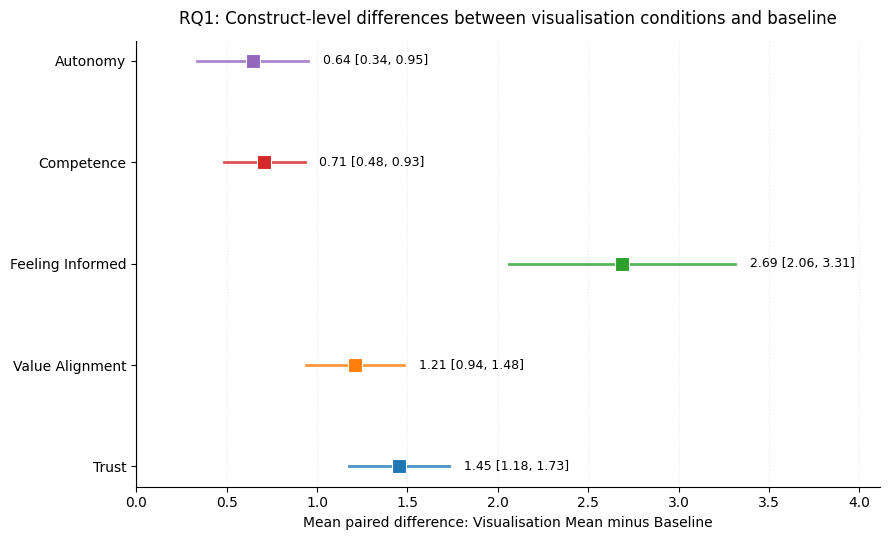

In [45]:
rq1_plot_data = rq1_construct_table.copy()


# Extract CI lower and upper values from the CI string
def extract_ci(ci_text):
    numbers = re.findall(r"-?\d+\.\d+", ci_text)
    return float(numbers[0]), float(numbers[1])

rq1_plot_data[["CI Low", "CI High"]] = rq1_plot_data[
    "95% CI for Mean Difference"
].apply(lambda x: pd.Series(extract_ci(x)))

# Order outcomes for display
outcome_order = [
    "Trust",
    "Value_Alignment",
    "Feeling_Informed",
    "Competence",
    "Autonomy"
]

rq1_plot_data["Outcome"] = pd.Categorical(
    rq1_plot_data["Outcome"],
    categories=outcome_order,
    ordered=True
)

rq1_plot_data = rq1_plot_data.sort_values("Outcome", ascending=True)

# Prepare plot
fig, ax = plt.subplots(figsize=(9, 5.5))

y_positions = np.arange(len(rq1_plot_data))

for i, (_, row) in enumerate(rq1_plot_data.iterrows()):
    mean_diff = row["Mean Paired Difference"]
    ci_low = row["CI Low"]
    ci_high = row["CI High"]

    # CI line
    ax.plot(
        [ci_low, ci_high],
        [i, i],
        linewidth=2,
        alpha=0.8
    )

    # Mean difference point
    ax.scatter(
        mean_diff,
        i,
        marker="s",
        s=90,
        edgecolor="white",
        linewidth=0.8,
        zorder=3
    )

    # Numeric label
    ax.text(
        ci_high + 0.08,
        i,
        f"{mean_diff:.2f} [{ci_low:.2f}, {ci_high:.2f}]",
        va="center",
        fontsize=9
    )

# Reference line at zero
ax.axvline(0, color="black", linewidth=0.8)

# Y-axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels(
    rq1_plot_data["Outcome"].astype(str).str.replace("_", " "),
    fontsize=10
)

ax.set_xlabel("Mean paired difference: Visualisation Mean minus Baseline", fontsize=10)
ax.set_title(
    "RQ1: Construct-level differences between visualisation conditions and baseline",
    fontsize=12,
    pad=12
)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.3)

# Adjust x-axis range
max_ci = rq1_plot_data["CI High"].max()
ax.set_xlim(0, max_ci + 0.8)

plt.tight_layout()
plt.savefig("Figure_RQ1_Construct_Level_Mean_Differences.png", dpi=300, bbox_inches="tight")
plt.show()

### RQ2: How do different value visualisation approaches influence users' trust, perceived autonomy, competence and feeling informed when interacting with chatbots?

#### Step 10: RQ2 Friedman Test for Visualisation-format Differences

This step examines whether participants' scores differed across the three value visualisation formats: Bar Chart (B), Radar Chart (C), and Polar Bar (D).

For each outcome, a Friedman test was conducted because the same participants experienced all three visualisation formats. The outcomes were Autonomy, Competence, Trust, Feeling Informed, and Value Alignment. Feeling Informed was treated as a single-item measure.

Holm correction was applied across the five outcome-level Friedman tests.

**Note on degrees of freedom:**

- For three visualisation conditions, df = k - 1 = 2, where k is the number of conditions.

In [46]:
# Compare the three visualisation formats: B = Bar Chart, C = Radar Chart, D = Polar Bar.
rq2_friedman_rows = []

for outcome in values_scale_cols:
    wide_outcome = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=outcome
    )

    friedman_stat, p_value = friedmanchisquare(
        wide_outcome["B"],
        wide_outcome["C"],
        wide_outcome["D"]
    )

    rq2_friedman_rows.append({
        "Outcome": outcome,
        "Friedman Chi-square": round(friedman_stat, 3),
        "df": 2,
        "p_raw_numeric": p_value,
        "p (raw)": format_p_cell(p_value)
    })

rq2_friedman_table = pd.DataFrame(rq2_friedman_rows)

# Apply Holm correction across the five outcome-level Friedman tests.
rq2_friedman_table = apply_holm_correction(
    rq2_friedman_table,
    p_col="p_raw_numeric"
)

rq2_friedman_table = rq2_friedman_table[
    [
        "Outcome",
        "Friedman Chi-square",
        "df",
        "p (raw)",
        "Holm-adjusted p",
        "Significant after Holm"
    ]
]

rq2_friedman_table

,Outcome,Friedman Chi-square,df,p (raw),Holm-adjusted p,Significant after Holm
0,Autonomy,9.162,2,.010,.031,Yes
1,Competence,5.365,2,.068,.088,No
2,Trust,13.169,2,.001,.007,Yes
3,Feeling_Informed,6.253,2,.044,.088,No
4,Value_Alignment,9.852,2,.007,.029,Yes


**Result Note:** The Friedman tests examined whether scores differed across the three visualisation formats: Bar Chart (B), Radar Chart (C), and Polar Bar (D). After Holm correction across the five outcome-level tests, significant format-level differences were observed for Autonomy, Trust, and Value Alignment.

- Autonomy showed a significant difference across the three visualisation formats, Friedman Chi-square(2) = 9.16, Holm-adjusted p = .031.
- Trust showed a significant difference across the three visualisation formats, Friedman Chi-square(2) = 13.17, Holm-adjusted p = .007.
- Value Alignment showed a significant difference across the three visualisation formats, Friedman Chi-square(2) = 9.85, Holm-adjusted p = .029.
- Competence and Feeling Informed did not show significant differences across the three visualisation formats after Holm correction, with Holm-adjusted p = .088 for both outcomes. The Friedman Chi-square values were 5.37 for Competence and 6.25 for Feeling Informed.

Overall, these results suggest that format-level differences were present for some outcomes, including Trust, Value Alignment, and Autonomy. Compared with the RQ1 baseline-versus-visualisation contrasts, format-level differences were smaller and more selective. The Friedman tests indicate whether a difference exists across the three formats, but they do not identify which specific formats differ. Pairwise comparisons are reported in the following step.

### Step 11: Raw Pairwise Wilcoxon Tests for Visualisation-format Comparisons
This step conducts raw pairwise Wilcoxon signed-rank tests among the three visualisation formats: Bar Chart (B), Radar Chart (C), and Polar Bar (D).

For each outcome, three pairwise comparisons were tested:
- B vs C
- B vs D
- C vs D


In [47]:
visualisation_conditions = ["B", "C", "D"]
format_pairs = list(combinations(visualisation_conditions, 2))

rq2_raw_wilcoxon_rows = []

for outcome in values_scale_cols:
    wide_outcome = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=outcome
    )

    for condition_1, condition_2 in format_pairs:
        w_stat, p_raw = wilcoxon(
            wide_outcome[condition_1],
            wide_outcome[condition_2],
            alternative="two-sided"
        )

        rq2_raw_wilcoxon_rows.append({
            "Outcome": outcome,
            "Comparison": f"Chatbot {condition_1} vs Chatbot {condition_2}",
            "Wilcoxon W": round(w_stat, 3),
            "p_raw_numeric": p_raw,
            "p (uncorrected)": format_p_cell(p_raw)
        })

rq2_raw_wilcoxon_table = pd.DataFrame(rq2_raw_wilcoxon_rows)

rq2_raw_wilcoxon_table[
    [
        "Outcome",
        "Comparison",
        "Wilcoxon W",
        "p (uncorrected)"
    ]
]

,Outcome,Comparison,Wilcoxon W,p (uncorrected)
0,Autonomy,Chatbot B vs Chatbot C,92.5,.020
1,Autonomy,Chatbot B vs Chatbot D,136.5,.963
2,Autonomy,Chatbot C vs Chatbot D,119.5,.153
3,Competence,Chatbot B vs Chatbot C,108.5,.145
4,Competence,Chatbot B vs Chatbot D,135.5,.306
5,Competence,Chatbot C vs Chatbot D,97.0,.209
6,Trust,Chatbot B vs Chatbot C,66.5,< .001
7,Trust,Chatbot B vs Chatbot D,100.0,.011
8,Trust,Chatbot C vs Chatbot D,137.5,.083
9,Feeling_Informed,Chatbot B vs Chatbot C,24.0,.019


**Result Note:** The raw pairwise Wilcoxon tests compared the three visualisation formats within each outcome: Bar Chart (B), Radar Chart (C), and Polar Bar (D). These p-values are uncorrected and are reported as an intermediate step before Holm correction.

For outcomes where the Friedman omnibus test remained significant after Holm correction (Autonomy, Trust, and Value Alignment), the raw pairwise results showed the following patterns:

- **Autonomy:** B vs C had a lower raw p-value, W = 92.5, raw p = .020. The B vs D and C vs D comparisons had higher raw p-values.
- **Trust:** B vs C showed the smallest raw p-value, W = 66.5, raw p < .001. B vs D had raw p = .011, W = 100.0. C vs D had raw p = .083, W = 137.5.
- **Value Alignment:** B vs C had raw p = .004, W = 56.0. B vs D had raw p = .038, W = 103.0. C vs D had raw p = .335, W = 149.0.

For outcomes where the Friedman omnibus test did not remain significant after Holm correction (Competence and Feeling Informed), the pairwise comparisons are treated as exploratory:

- **Competence:** all three raw p-values were above .05: B vs C, raw p = .145; B vs D, raw p = .306; C vs D, raw p = .209.
- **Feeling Informed:** B vs C had raw p = .019, W = 24.0. B vs D had raw p = .354, and C vs D had raw p = .057. Since the omnibus test for Feeling Informed did not remain significant after Holm correction, these pairwise values are treated only as exploratory.

Across the five outcomes, the B vs C comparison appeared most often among the lower raw p-values. This is a descriptive pattern only. It suggests that the Bar Chart and Radar Chart may differ more than the other format pairs, pending the Holm-corrected results reported in the next step.

These raw p-values have not been corrected for multiple comparisons. Holm-adjusted p-values are reported in the next step and are used for the final pairwise interpretation.

### Step 12: RQ2 Pairwise Summary Table with Holm Correction
This step summarises all pairwise comparisons among the three visualisation formats: Bar Chart (B), Radar Chart (C), and Polar Bar (D).
For each outcome, three pairwise comparisons were reported:

- B vs C
- B vs D
- C vs D

Holm correction was applied separately within each outcome across these three comparisons. Each correction family therefore contained three pairwise tests. The table reports all comparisons, including non-significant comparisons. For each comparison, it includes condition-level means and medians, mean paired difference, 95% confidence interval for the mean paired difference, Wilcoxon W, raw p-value, Holm-adjusted p-value, and Cohen’s dz effect size.

In [48]:
# Direction of comparison: Condition 1 - Condition 2
# Holm correction is applied separately within each outcome.
# Family size within each outcome = 3 comparisons: B vs C, B vs D, C vs D.
visualisation_conditions = ["B", "C", "D"]
format_pairs = list(combinations(visualisation_conditions, 2))

rq2_pairwise_rows = []

for outcome in values_scale_cols:
    wide = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=outcome
    )

    outcome_raw_table = rq2_raw_wilcoxon_table[
        rq2_raw_wilcoxon_table["Outcome"] == outcome
    ].reset_index(drop=True)

    # Apply Holm correction within this outcome only
    reject, p_holm, _, _ = multipletests(
        outcome_raw_table["p_raw_numeric"].values,
        alpha=0.05,
        method="holm"
    )

    for i, (condition_1, condition_2) in enumerate(format_pairs):
        condition_1_scores = wide[condition_1].astype(float)
        condition_2_scores = wide[condition_2].astype(float)

        # Direction: condition_1 - condition_2
        diff = condition_1_scores - condition_2_scores

        mean_diff, ci_low, ci_high = paired_mean_diff_ci(diff)
        dz = mean_diff / diff.std(ddof=1)

        # Parametric robustness check
        t_stat, p_ttest = ttest_rel(condition_1_scores, condition_2_scores)

        rq2_pairwise_rows.append({
            "Outcome": outcome,
            "Comparison": f"Chatbot {condition_1} vs Chatbot {condition_2}",
            "Condition 1 M (SD)": mean_sd(condition_1_scores),
            "Condition 2 M (SD)": mean_sd(condition_2_scores),
            "Condition 1 Median (IQR)": median_iqr(condition_1_scores),
            "Condition 2 Median (IQR)": median_iqr(condition_2_scores),
            "Mean Paired Difference": round(mean_diff, 3),
            "95% CI for Mean Difference": f"[{ci_low:.3f}, {ci_high:.3f}]",
            "Wilcoxon W": outcome_raw_table.loc[i, "Wilcoxon W"],
            "p (uncorrected)": format_p_cell(outcome_raw_table.loc[i, "p_raw_numeric"]),
            "Holm-adjusted p": format_p_cell(p_holm[i]),
            "Significant after Holm": interpret_significance(p_holm[i]),
            "Cohen's dz": round(dz, 3),
            "Effect Size": interpret_cohens_dz(dz),
            "t (df=29)": round(t_stat, 3),
            "p (t-test robustness)": format_p_cell(p_ttest)
        })

rq2_pairwise_table = pd.DataFrame(rq2_pairwise_rows)

rq2_pairwise_table

,Outcome,Comparison,Condition 1 M (SD),Condition 2 M (SD),Condition 1 Median (IQR),Condition 2 Median (IQR),Mean Paired Difference,95% CI for Mean Difference,Wilcoxon W,p (uncorrected),Holm-adjusted p,Significant after Holm,Cohen's dz,Effect Size,t (df=29),p (t-test robustness)
0,Autonomy,Chatbot B vs Chatbot C,5.52 (0.57),5.18 (0.68),5.50 (5.33-5.92),5.33 (4.75-5.67),0.344,"[0.084, 0.605]",92.5,.020,.060,No,0.494,Small,2.705,.011
1,Autonomy,Chatbot B vs Chatbot D,5.52 (0.57),5.40 (0.66),5.50 (5.33-5.92),5.67 (5.08-6.00),0.122,"[-0.180, 0.424]",136.5,.963,.963,No,0.151,Very small,0.827,.415
2,Autonomy,Chatbot C vs Chatbot D,5.18 (0.68),5.40 (0.66),5.33 (4.75-5.67),5.67 (5.08-6.00),-0.222,"[-0.595, 0.151]",119.5,.153,.306,No,-0.222,Small,-1.218,.233
3,Competence,Chatbot B vs Chatbot C,5.51 (0.72),5.27 (0.67),5.67 (5.08-6.00),5.33 (5.00-5.67),0.244,"[-0.125, 0.614]",108.5,.145,.435,No,0.247,Small,1.352,.187
4,Competence,Chatbot B vs Chatbot D,5.51 (0.72),5.41 (0.59),5.67 (5.08-6.00),5.33 (5.00-5.67),0.100,"[-0.198, 0.398]",135.5,.306,.435,No,0.125,Very small,0.686,.498
5,Competence,Chatbot C vs Chatbot D,5.27 (0.67),5.41 (0.59),5.33 (5.00-5.67),5.33 (5.00-5.67),-0.144,"[-0.436, 0.147]",97.0,.209,.435,No,-0.185,Very small,-1.012,.320
6,Trust,Chatbot B vs Chatbot C,5.66 (0.51),5.16 (0.47),5.71 (5.25-6.08),5.21 (4.77-5.54),0.500,"[0.261, 0.739]",66.5,< .001,.002,Yes,0.783,Medium,4.287,< .001
7,Trust,Chatbot B vs Chatbot D,5.66 (0.51),5.37 (0.38),5.71 (5.25-6.08),5.33 (5.10-5.58),0.289,"[0.082, 0.496]",100.0,.011,.022,Yes,0.521,Medium,2.854,.008
8,Trust,Chatbot C vs Chatbot D,5.16 (0.47),5.37 (0.38),5.21 (4.77-5.54),5.33 (5.10-5.58),-0.211,"[-0.437, 0.015]",137.5,.083,.083,No,-0.349,Small,-1.911,.066
9,Feeling_Informed,Chatbot B vs Chatbot C,6.10 (0.76),5.53 (1.22),6.00 (6.00-7.00),6.00 (5.00-6.00),0.567,"[0.100, 1.034]",24.0,.019,.056,No,0.453,Small,2.482,.019


**Result note:**  

The Holm-corrected pairwise comparisons show that format-level differences were limited to Trust and Value Alignment.

- **Trust:** the Bar Chart condition had higher scores than both the Radar Chart and the Polar Bar condition. The Bar Chart was higher than the Radar Chart, with a mean paired difference of 0.50, 95% CI [0.26, 0.74], Holm-adjusted p = .002, and a medium effect size, Cohen's dz = 0.78. The Bar Chart was also higher than the Polar Bar, with a mean paired difference of 0.29, 95% CI [0.08, 0.50], Holm-adjusted p = .022, and a medium effect size, Cohen's dz = 0.52. The Radar Chart and Polar Bar comparison was not significant after Holm correction, Holm-adjusted p = .083.

- **Value Alignment:** the Bar Chart condition was higher than the Radar Chart condition, with a mean paired difference of 0.37, 95% CI [0.14, 0.59], Holm-adjusted p = .012, and a medium effect size, Cohen's dz = 0.61. The Bar Chart and Polar Bar comparison did not remain significant after Holm correction, Holm-adjusted p = .077. The Radar Chart and Polar Bar comparison was also not significant, Holm-adjusted p = .335.

- **Autonomy:** the Friedman test suggested an overall format-level difference, but none of the pairwise comparisons remained significant after Holm correction. The closest comparison was Bar Chart vs Radar Chart, with a mean paired difference of 0.34 and Holm-adjusted p = .060. This suggests a possible descriptive tendency for higher Autonomy ratings in the Bar Chart condition compared with the Radar Chart condition, although this should not be treated as a statistically significant pairwise difference.

- **Competence and Feeling Informed:** the Friedman omnibus tests did not remain significant after Holm correction, so the pairwise results for these outcomes are reported as exploratory. None of the pairwise comparisons reached significance after Holm correction, with all Holm-adjusted p-values at or above .056. The closest exploratory comparison was Bar Chart vs Radar Chart for Feeling Informed, Holm-adjusted p = .056. These should be treated as descriptive patterns only.

Overall, the pairwise results suggest that differences between visualisation formats were selective. The clearest format-level pattern was for Trust, where the Bar Chart received higher scores than both the Radar Chart and the Polar Bar condition. Value Alignment also showed a significant difference between the Bar Chart and the Radar Chart. Other format comparisons did not remain significant after Holm correction.

Within the RQ2 correction framework, the format-level differences detected after Holm correction were mainly associated with the Bar Chart. The Polar Bar is examined separately in RQ3, where comparisons with the standard formats are interpreted using the RQ3-specific comparison structure.

#### Step 13: Figure for RQ2
- Multi-panel forest plot of pairwise effect sizes (Cohen's dz with 95% CI)
- for the three visualisation formats only: B vs C, B vs D, C vs D.

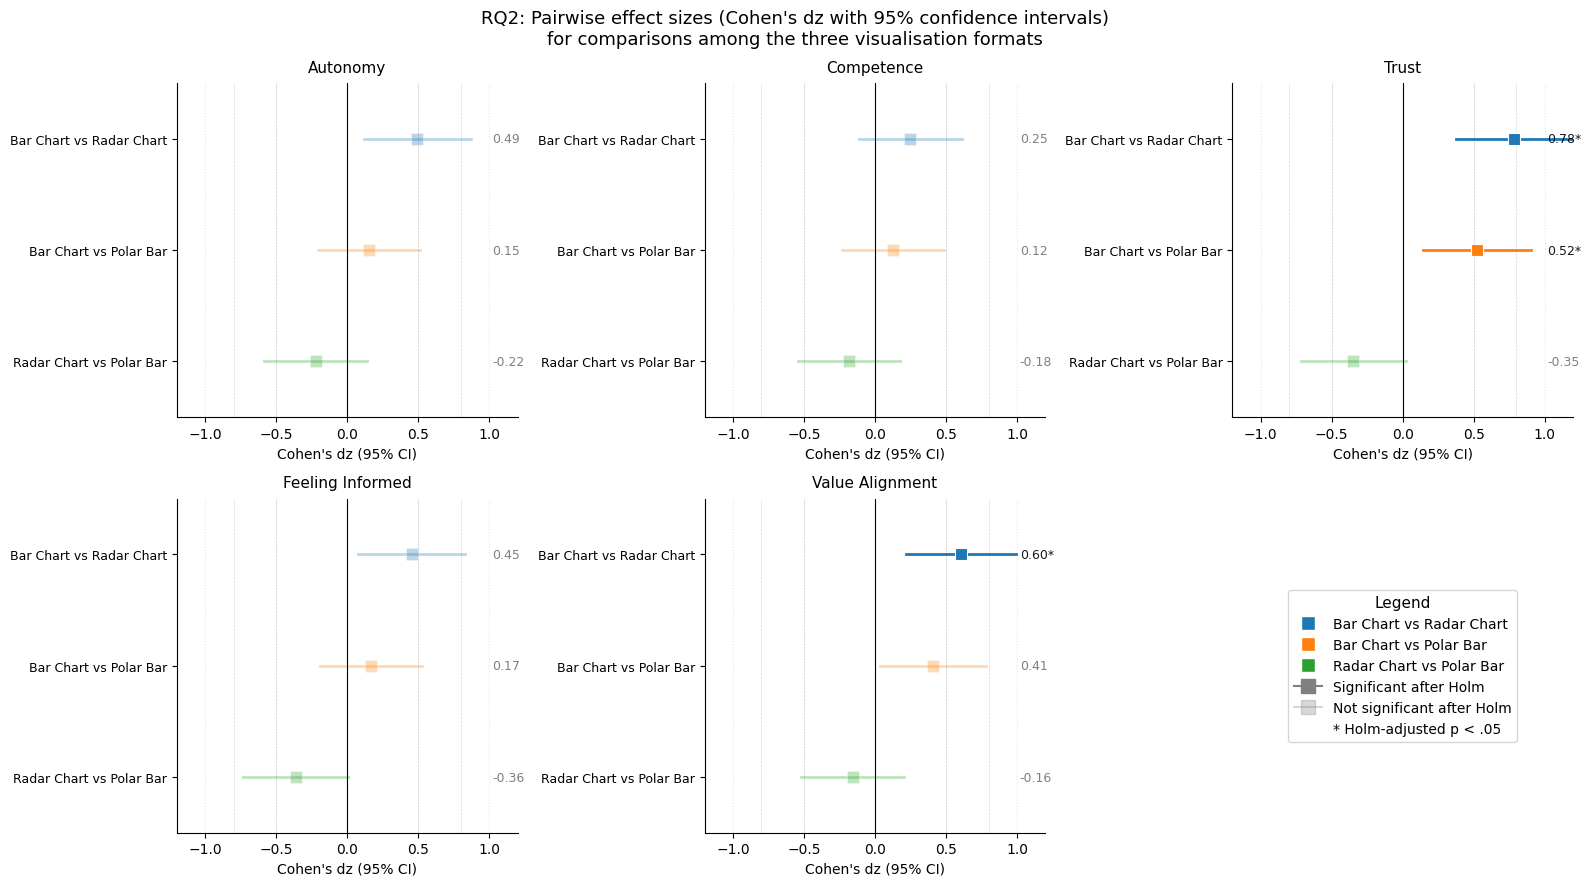

In [49]:
n = 30  # paired observations

# Outcomes in dissertation order
rq2_outcomes = [
    "Autonomy",
    "Competence",
    "Trust",
    "Feeling_Informed",
    "Value_Alignment"
]

# Pair order to display within each panel
rq2_pairs = [
    ("B", "C"),
    ("B", "D"),
    ("C", "D")
]

# Labels for conditions
condition_labels = {
    "B": "Bar Chart",
    "C": "Radar Chart",
    "D": "Polar Bar"
}

# Labels for pairwise comparisons
pair_labels = [
    f"{condition_labels[c1]} vs {condition_labels[c2]}"
    for c1, c2 in rq2_pairs
]

# Optional colours for the three pair types
pair_colors = {
    ("B", "C"): "#1f77b4",
    ("B", "D"): "#ff7f0e",
    ("C", "D"): "#2ca02c"
}

# Create 2 x 3 layout (5 outcome panels + 1 legend panel)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for idx, outcome in enumerate(rq2_outcomes):
    ax = axes_flat[idx]

    for i, (cond1, cond2) in enumerate(rq2_pairs):
        comparison_str = f"Chatbot {cond1} vs Chatbot {cond2}"

        row = rq2_pairwise_table[
            (rq2_pairwise_table["Outcome"] == outcome) &
            (rq2_pairwise_table["Comparison"] == comparison_str)
        ]

        dz = row["Cohen's dz"].values[0]
        sig = row["Significant after Holm"].values[0] == "Yes"

        # Approximate 95% CI for paired Cohen's dz
        se = np.sqrt((1 / n) + (dz**2 / (2 * n)))
        ci_low = dz - 1.96 * se
        ci_high = dz + 1.96 * se

        y = len(rq2_pairs) - 1 - i
        color = pair_colors[(cond1, cond2)]
        alpha = 1.0 if sig else 0.30

        # CI line
        ax.plot(
            [ci_low, ci_high], [y, y],
            color=color, linewidth=2, alpha=alpha
        )

        # Effect size point
        ax.scatter(
            dz, y,
            color=color, s=80, marker="s",
            edgecolor="white", linewidth=0.8,
            zorder=3, alpha=alpha
        )

        # Numeric label
        sig_marker = "*" if sig else ""
        ax.text(
            1.02, y,
            f"{dz:.2f}{sig_marker}",
            fontsize=9, va="center",
            alpha=0.9 if sig else 0.5
        )

    # Reference lines
    ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)
    ax.axvline(-0.5, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)
    ax.axvline(0.8, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)
    ax.axvline(-0.8, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)

    # Y-axis
    ax.set_yticks(range(len(rq2_pairs))[::-1])
    ax.set_yticklabels(pair_labels, fontsize=9)

    # X-axis
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.5, len(rq2_pairs) - 0.5)
    ax.set_xlabel("Cohen's dz (95% CI)", fontsize=10)

    # Outcome title
    ax.set_title(outcome.replace("_", " "), fontsize=11, pad=8)

    # Clean style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.3)

# Last panel used for legend
axes_flat[5].axis("off")

legend_handles = [
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor=pair_colors[("B", "C")],
           markersize=10, label="Bar Chart vs Radar Chart"),
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor=pair_colors[("B", "D")],
           markersize=10, label="Bar Chart vs Polar Bar"),
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor=pair_colors[("C", "D")],
           markersize=10, label="Radar Chart vs Polar Bar"),
    Line2D([0], [0], marker="s", color="gray",
           markerfacecolor="gray", alpha=1.0,
           markersize=10, label="Significant after Holm"),
    Line2D([0], [0], marker="s", color="gray",
           markerfacecolor="gray", alpha=0.30,
           markersize=10, label="Not significant after Holm"),
    Line2D([0], [0], marker="", color="w",
           label="* Holm-adjusted p < .05")
]

axes_flat[5].legend(
    handles=legend_handles,
    loc="center",
    fontsize=10,
    frameon=True,
    title="Legend",
    title_fontsize=11
)

fig.suptitle(
    "RQ2: Pairwise effect sizes (Cohen's dz with 95% confidence intervals)\n"
    "for comparisons among the three visualisation formats",
    fontsize=13,
    y=0.98
)

plt.tight_layout()
plt.savefig("Figure_RQ2_Pairwise_Effect_Sizes_Holm.png", dpi=300, bbox_inches="tight")
plt.show()

### RQ3: How do user-designed value visualisations compare to standard visualisation formats (such as bar and radar charts) in terms of impacting user perceptions?
#### Step 14: RQ3 Focused View of Polar Bar Comparisons

RQ3 examines how the user-designed Polar Bar visualisation (D) compared with the two standard visualisation formats: Bar Chart (B) and Radar Chart (C).

This step extracts the Polar Bar comparisons from the RQ2 visualisation-format comparison table. The same Holm-adjusted results are used, so the correction family remains consistent with RQ2: three visualisation-format comparisons within each outcome.

The comparisons are presented from the Polar Bar perspective:

- Polar Bar (D) vs Bar Chart (B)
- Polar Bar (D) vs Radar Chart (C)


In [50]:
def invert_ci_string(ci_text):
    """
    Invert a CI string when reversing the direction of a comparison.
    Example: [0.082, 0.496] becomes [-0.496, -0.082]
    """
    numbers = re.findall(r"-?\d+\.\d+", ci_text)
    ci_low = float(numbers[0])
    ci_high = float(numbers[1])
    return f"[{-ci_high:.3f}, {-ci_low:.3f}]"


rq3_rows = []

standard_formats = {
    "B": "Bar Chart",
    "C": "Radar Chart"
}

for outcome in values_scale_cols:
    for standard_condition, standard_label in standard_formats.items():

        # In rq2_pairwise_table, comparisons are stored as Standard vs D:
        # B vs D or C vs D.
        rq2_comparison = f"Chatbot {standard_condition} vs Chatbot D"

        row = rq2_pairwise_table[
            (rq2_pairwise_table["Outcome"] == outcome) &
            (rq2_pairwise_table["Comparison"] == rq2_comparison)
        ].iloc[0]

        rq3_rows.append({
            "Outcome": outcome,
            "Comparison": f"Polar Bar D vs {standard_label} ({standard_condition})",
            "Polar Bar M (SD)": row["Condition 2 M (SD)"],
            "Standard Format M (SD)": row["Condition 1 M (SD)"],
            "Polar Bar Median (IQR)": row["Condition 2 Median (IQR)"],
            "Standard Format Median (IQR)": row["Condition 1 Median (IQR)"],
            "Mean Paired Difference (D - Standard)": round(
                -row["Mean Paired Difference"], 3
            ),
            "95% CI for Mean Difference": invert_ci_string(
                row["95% CI for Mean Difference"]
            ),
            "Wilcoxon W": row["Wilcoxon W"],
            "p (uncorrected)": row["p (uncorrected)"],
            "Holm-adjusted p": row["Holm-adjusted p"],
            "Significant after Holm": row["Significant after Holm"],
            "Cohen's dz (D vs Standard)": round(
                -row["Cohen's dz"], 3
            ),
            "Effect Size": row["Effect Size"]
        })

rq3_focused_table = pd.DataFrame(rq3_rows)

rq3_focused_table

,Outcome,Comparison,Polar Bar M (SD),Standard Format M (SD),Polar Bar Median (IQR),Standard Format Median (IQR),Mean Paired Difference (D - Standard),95% CI for Mean Difference,Wilcoxon W,p (uncorrected),Holm-adjusted p,Significant after Holm,Cohen's dz (D vs Standard),Effect Size
0,Autonomy,Polar Bar D vs Bar Chart (B),5.40 (0.66),5.52 (0.57),5.67 (5.08-6.00),5.50 (5.33-5.92),-0.122,"[-0.424, 0.180]",136.5,.963,.963,No,-0.151,Very small
1,Autonomy,Polar Bar D vs Radar Chart (C),5.40 (0.66),5.18 (0.68),5.67 (5.08-6.00),5.33 (4.75-5.67),0.222,"[-0.151, 0.595]",119.5,.153,.306,No,0.222,Small
2,Competence,Polar Bar D vs Bar Chart (B),5.41 (0.59),5.51 (0.72),5.33 (5.00-5.67),5.67 (5.08-6.00),-0.100,"[-0.398, 0.198]",135.5,.306,.435,No,-0.125,Very small
3,Competence,Polar Bar D vs Radar Chart (C),5.41 (0.59),5.27 (0.67),5.33 (5.00-5.67),5.33 (5.00-5.67),0.144,"[-0.147, 0.436]",97.0,.209,.435,No,0.185,Very small
4,Trust,Polar Bar D vs Bar Chart (B),5.37 (0.38),5.66 (0.51),5.33 (5.10-5.58),5.71 (5.25-6.08),-0.289,"[-0.496, -0.082]",100.0,.011,.022,Yes,-0.521,Medium
5,Trust,Polar Bar D vs Radar Chart (C),5.37 (0.38),5.16 (0.47),5.33 (5.10-5.58),5.21 (4.77-5.54),0.211,"[-0.015, 0.437]",137.5,.083,.083,No,0.349,Small
6,Feeling_Informed,Polar Bar D vs Bar Chart (B),5.93 (0.69),6.10 (0.76),6.00 (5.25-6.00),6.00 (6.00-7.00),-0.167,"[-0.535, 0.201]",82.0,.354,.354,No,-0.169,Very small
7,Feeling_Informed,Polar Bar D vs Radar Chart (C),5.93 (0.69),5.53 (1.22),6.00 (5.25-6.00),6.00 (5.00-6.00),0.400,"[-0.011, 0.811]",51.0,.057,.113,No,0.363,Small
8,Value_Alignment,Polar Bar D vs Bar Chart (B),5.49 (0.53),5.74 (0.57),5.57 (5.14-5.86),5.71 (5.32-6.14),-0.257,"[-0.492, -0.023]",103.0,.038,.077,No,-0.409,Small
9,Value_Alignment,Polar Bar D vs Radar Chart (C),5.49 (0.53),5.38 (0.59),5.57 (5.14-5.86),5.36 (4.89-5.86),0.110,"[-0.149, 0.368]",149.0,.335,.335,No,0.158,Very small


**Result Note:** The RQ3-focused table presents the Polar Bar comparisons using the same visualisation-format comparison framework as RQ2. The direction of the mean paired difference is Polar Bar minus the standard format. Positive values indicate higher scores for the Polar Bar condition, while negative values indicate lower scores for the Polar Bar condition.

- Compared with the Bar Chart, the Polar Bar had numerically lower scores across all five outcomes. The only comparison that remained significant after Holm correction was Trust. For Trust, the Polar Bar scored lower than the Bar Chart, with a mean paired difference of -0.29, 95% CI [-0.50, -0.08], Holm-adjusted p = .022, and a medium effect size, Cohen’s dz = -0.52. The other Polar Bar versus Bar Chart comparisons did not remain significant after Holm correction. Value Alignment showed a descriptive lower score for the Polar Bar, mean paired difference = -0.26, 95% CI [-0.49, -0.02], but this comparison did not remain significant after Holm correction, Holm-adjusted p = .077.
- Compared with the Radar Chart, the Polar Bar had numerically higher scores across all five outcomes. However, none of the Polar Bar versus Radar Chart comparisons remained significant after Holm correction. The largest descriptive differences were observed for Feeling Informed, mean paired difference = 0.40, and Trust, mean paired difference = 0.21, but these should be treated as descriptive patterns only.

Overall, the RQ3-focused results suggest that the Polar Bar tended to fall between the Bar Chart and Radar Chart. It scored lower than the Bar Chart across all five outcomes and higher than the Radar Chart across all five outcomes. Within this comparison framework, the only statistically significant Polar Bar comparison was for Trust, where the Polar Bar scored lower than the Bar Chart.

These findings should be interpreted cautiously. The non-significant comparisons do not demonstrate equivalence between the Polar Bar and the standard formats, since no equivalence or non-inferiority test was conducted. With only 30 participants, the study may also have been underpowered to detect some moderate format differences. The results show that no significant differences were observed for most Polar Bar comparisons in this sample, with the exception of Trust compared with the Bar Chart.


## Secondary Analysis: User-defined Value Adjustments
- This section presents a supplementary descriptive analysis based on a separate dataset capturing how participants adjusted the chatbot’s displayed value priorities. The adjustment task was available only in the three visualisation conditions: Bar Chart (B), Radar Chart (C), and Polar Bar (D). It was not available in the baseline condition.
- In each visualisation condition, participants were given the option to adjust five system-defined values: Privacy, Informed Consent, Autonomy, Universal Usability, and Courtesy. These adjustments provide a behavioural lens on how participants engaged with visible value profiles when such profiles were available.

This analysis complements the questionnaire-based results by showing how participants interacted with the displayed value levels. It does not directly test visualisation versus no visualisation because the baseline condition did not include an adjustment task. The results are therefore interpreted descriptively.

### Step 15: Load User-defined Value Dataset

- This step loads the user-defined value dataset. The dataset records participants’ selected value levels under the three visualisation conditions: Bar Chart, Radar Chart, and Polar Bar.

- Each participant completed the value-adjustment task once per visualisation condition. The expected dataset structure is therefore 30 participants × 3 visualisation conditions = 90 participant-condition rows.

In [51]:
df_user_defined_values = pd.read_excel(
    "User_defined_Value_Result.xlsx",
    sheet_name=0
)

# Inspect basic structure
print(f"Dataset shape: {df_user_defined_values.shape[0]} rows x {df_user_defined_values.shape[1]} columns")

print("\nColumn names:")
print(list(df_user_defined_values.columns))

print("\nConditions in dataset:")
print(df_user_defined_values["condition"].value_counts())

print("\nNumber of unique participant base IDs:")
print(df_user_defined_values["participant_base_id"].nunique())

df_user_defined_values.head()

Dataset shape: 90 rows x 10 columns

Column names:
['participant_base_id', 'participant_id', 'condition', 'mode', 'timestamp', 'Privacy', 'Informed Consent', 'Courtesy', 'Autonomy', 'Universal Usability']

Conditions in dataset:
condition
bar         30
radar       30
codesign    30
Name: count, dtype: int64

Number of unique participant base IDs:
30


,participant_base_id,participant_id,condition,mode,timestamp,Privacy,Informed Consent,Courtesy,Autonomy,Universal Usability
0,1,PB001,bar,user_defined,2026-04-08 12:25:40,1,2,3,1,2
1,1,PR001,radar,user_defined,2026-04-08 12:43:30,1,2,3,1,2
2,1,PC001,codesign,user_defined,2026-04-08 13:02:26,1,2,3,1,3
3,2,PB002,bar,user_defined,2026-04-08 12:38:12,1,2,3,2,3
4,2,PC002,codesign,user_defined,2026-04-08 12:53:22,1,2,3,2,3


### Step 16: Reshape Data and Compute Modification Variables

This step reshapes the user-defined value dataset from participant-condition format into value-level long format. Each row in the reshaped dataset represents one participant’s selected level for one value in one visualisation condition.

The value levels were coded as:

- Low = 1
- Medium = 2
- High = 3

The system-defined default values were fixed across all three visualisation conditions:

- Privacy = Low (1)
- Informed Consent = Low (1)
- Autonomy = Medium (2)
- Universal Usability = High (3)
- Courtesy = High (3)

For each value-level row, three variables were calculated:

- Modified: whether the participant’s selected level differed from the system default
- Direction: whether the selected level increased, decreased, or remained unchanged relative to the default
- Signed_Change: the selected level minus the system default

The reshaped dataset contains 450 value-level rows: 30 participants × 3 visualisation conditions × 5 values. These rows are nested within participants and conditions, so they are treated descriptively rather than as independent observations.


In [52]:
# Value level coding:
# Low = 1, Medium = 2, High = 3
level_labels = {
    1: "Low",
    2: "Medium",
    3: "High"
}

# System defaults
system_defaults_values_setting = {
    "Privacy": 1,
    "Informed Consent": 1,
    "Autonomy": 2,
    "Universal Usability": 3,
    "Courtesy": 3
}

# Map condition codes to match the main analysis
visualisation_chatbot_condition_map = {
    "bar": "B",
    "radar": "C",
    "codesign": "D"
}

condition_labels = {
    "B": "Bar Chart",
    "C": "Radar Chart",
    "D": "Polar Bar"
}

df_user_defined_values["Condition"] = df_user_defined_values["condition"].map(
    visualisation_chatbot_condition_map
)

df_user_defined_values["Condition_Label"] = df_user_defined_values["Condition"].map(
    condition_labels
)

# Reshape to long format
value_cols = [
    "Privacy",
    "Informed Consent",
    "Courtesy",
    "Autonomy",
    "Universal Usability"
]

user_modifications = df_user_defined_values.melt(
    id_vars=["participant_base_id", "Condition", "Condition_Label"],
    value_vars=value_cols,
    var_name="Value",
    value_name="User_Choice"
)

# Add system default
user_modifications["System_Default"] = user_modifications["Value"].map(
    system_defaults_values_setting
)

# Modification flag
user_modifications["Modified"] = (
    user_modifications["User_Choice"] != user_modifications["System_Default"]
)

# Signed change from default
user_modifications["Signed_Change"] = (
    user_modifications["User_Choice"] - user_modifications["System_Default"]
)

# Direction of change
user_modifications["Direction"] = np.where(
    user_modifications["Signed_Change"] == 0,
    "Unchanged",
    np.where(user_modifications["Signed_Change"] > 0, "Increased", "Decreased")
)

# Add readable labels
user_modifications["User_Choice_Label"] = user_modifications["User_Choice"].map(
    level_labels
)

user_modifications["System_Default_Label"] = user_modifications["System_Default"].map(
    level_labels
)

# Sanity check
print(f"Total value-level rows: {len(user_modifications)}")
print("Expected: 30 participants × 3 conditions × 5 values = 450")

print("\nDirection distribution:")
print(user_modifications["Direction"].value_counts())

print("\nSigned change distribution:")
print(user_modifications["Signed_Change"].value_counts().sort_index())

user_modifications.head(15)

Total value-level rows: 450
Expected: 30 participants × 3 conditions × 5 values = 450

Direction distribution:
Direction
Unchanged    218
Increased    119
Decreased    113
Name: count, dtype: int64

Signed change distribution:
Signed_Change
-2     18
-1     95
 0    218
 1     89
 2     30
Name: count, dtype: int64


,participant_base_id,Condition,Condition_Label,Value,User_Choice,System_Default,Modified,Signed_Change,Direction,User_Choice_Label,System_Default_Label
0,1,B,Bar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
1,1,C,Radar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
2,1,D,Polar Bar,Privacy,1,1,False,0,Unchanged,Low,Low
3,2,B,Bar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
4,2,D,Polar Bar,Privacy,1,1,False,0,Unchanged,Low,Low
5,2,C,Radar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
6,3,D,Polar Bar,Privacy,1,1,False,0,Unchanged,Low,Low
7,3,C,Radar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
8,3,B,Bar Chart,Privacy,1,1,False,0,Unchanged,Low,Low
9,4,D,Polar Bar,Privacy,2,1,True,1,Increased,Medium,Low


**Result Note:**
The user-defined value dataset was successfully reshaped into 450 value-level rows, matching the expected structure of 30 participants × 3 visualisation conditions × 5 values. Each row represents one participant’s selected level for one value in one visualisation condition.

- Across the 450 value-level observations, 218 observations were unchanged, 119 were increased, and 113 were decreased. The signed change distribution showed that most observations either remained unchanged or moved by one level from the system default. Specifically, 218 observations had no change, 89 increased by one level, 30 increased by two levels, 95 decreased by one level, and 18 decreased by two levels.

This suggests that participants used the adjustment task in both directions where the value defaults allowed it. However, these patterns should be interpreted descriptively because the value-level rows are nested within participants and visualisation conditions. The signed changes are also shaped by the system defaults and the resulting ceiling and floor constraints: Privacy and Informed Consent started at Low, Universal Usability and Courtesy started at High, and Autonomy started at Medium.

#### Step 17: Modification Rates and Direction by Value

This step summarises how often each value was modified from the system default and the direction of those modifications.

In [53]:
value_modification_summary = (
    user_modifications
    .groupby("Value")
    .agg(
        Total=("Modified", "count"),
        Changed_Count=("Modified", "sum")
    )
    .reset_index()
)

value_modification_summary["Unchanged_Count"] = (
    value_modification_summary["Total"] - value_modification_summary["Changed_Count"]
)

value_modification_summary["Change_Rate (%)"] = (
    value_modification_summary["Changed_Count"] /
    value_modification_summary["Total"] * 100
).round(1)

# Add system default labels for interpretation
default_labels = {
    "Privacy": "Low",
    "Informed Consent": "Low",
    "Autonomy": "Medium",
    "Universal Usability": "High",
    "Courtesy": "High"
}

value_modification_summary["System Default"] = (
    value_modification_summary["Value"].map(default_labels)
)

# Reorder columns
value_modification_summary = value_modification_summary[
    [
        "Value",
        "System Default",
        "Total",
        "Changed_Count",
        "Unchanged_Count",
        "Change_Rate (%)"
    ]
]

value_modification_summary = value_modification_summary.sort_values(
    "Change_Rate (%)",
    ascending=False
).reset_index(drop=True)

value_modification_summary

,Value,System Default,Total,Changed_Count,Unchanged_Count,Change_Rate (%)
0,Autonomy,Medium,90,55,35,61.1
1,Courtesy,High,90,50,40,55.6
2,Informed Consent,Low,90,46,44,51.1
3,Privacy,Low,90,43,47,47.8
4,Universal Usability,High,90,38,52,42.2


**Result Note:**
The modification rates varied across the five values. Autonomy had the highest observed change rate, with 55 out of 90 observations modified (61.1%). Courtesy was modified in 50 out of 90 observations (55.6%), followed by Informed Consent (51.1%), Privacy (47.8%), and Universal Usability (42.2%).

These modification rates should be interpreted alongside the system defaults. Autonomy started at Medium, which allowed participants to adjust it either upward or downward. This makes its change rate less directly comparable with the other values. Privacy and Informed Consent started at Low, so they could only increase or remain unchanged. Courtesy and Universal Usability started at High, so they could only decrease or remain unchanged.

The results suggest that participants frequently adjusted the visible value profile when the adjustment task was available. However, the observed differences in modification rates should be treated descriptively because they are shaped by the initial default levels and the ceiling and floor constraints.

### Step 17a: Direction of Modification by Value

This step summarises whether each value was increased, decreased, or left unchanged from the system default.

In [54]:
direction_by_value = (
    user_modifications
    .groupby(["Value", "Direction"])
    .size()
    .reset_index(name="Count")
)

direction_by_value_pivot = direction_by_value.pivot(
    index="Value",
    columns="Direction",
    values="Count"
).fillna(0).astype(int)

# Ensure all direction columns exist
for col in ["Increased", "Decreased", "Unchanged"]:
    if col not in direction_by_value_pivot.columns:
        direction_by_value_pivot[col] = 0

# Add row-wise total
direction_by_value_pivot["Total"] = direction_by_value_pivot[
    ["Increased", "Decreased", "Unchanged"]
].sum(axis=1)

# Add percentage columns
direction_by_value_pivot["Increased (%)"] = (
    direction_by_value_pivot["Increased"] / direction_by_value_pivot["Total"] * 100
).round(1)

direction_by_value_pivot["Decreased (%)"] = (
    direction_by_value_pivot["Decreased"] / direction_by_value_pivot["Total"] * 100
).round(1)

direction_by_value_pivot["Unchanged (%)"] = (
    direction_by_value_pivot["Unchanged"] / direction_by_value_pivot["Total"] * 100
).round(1)

# Add system default for interpretation
default_labels = {
    "Privacy": "Low",
    "Informed Consent": "Low",
    "Autonomy": "Medium",
    "Universal Usability": "High",
    "Courtesy": "High"
}

direction_by_value_pivot["System Default"] = (
    direction_by_value_pivot.index.map(default_labels)
)

# Reorder columns
direction_by_value_pivot = direction_by_value_pivot[
    [
        "System Default",
        "Increased",
        "Decreased",
        "Unchanged",
        "Total",
        "Increased (%)",
        "Decreased (%)",
        "Unchanged (%)"
    ]
]

direction_by_value_pivot

Direction,System Default,Increased,Decreased,Unchanged,Total,Increased (%),Decreased (%),Unchanged (%)
Value,,,,,,,,
Autonomy,Medium,30,25,35,90,33.3,27.8,38.9
Courtesy,High,0,50,40,90,0.0,55.6,44.4
Informed Consent,Low,46,0,44,90,51.1,0.0,48.9
Privacy,Low,43,0,47,90,47.8,0.0,52.2
Universal Usability,High,0,38,52,90,0.0,42.2,57.8


**Result Note:**
The direction of modifications varied by value and should be interpreted together with the system default.

- **Autonomy** started at Medium and was the only value that could move in both directions. It was increased in 30 out of 90 observations (33.3%), decreased in 25 observations (27.8%), and left unchanged in 35 observations (38.9%). This suggests mixed participant responses to the appropriate level of autonomy in the chatbot, although this pattern should be interpreted descriptively.

- For values that started at Low, changes could only move upward or remain unchanged. **Informed Consent** was increased in 46 out of 90 observations (51.1%), while **Privacy** was increased in 43 out of 90 observations (47.8%). This suggests that many participants selected higher levels for these values than the system default.

- For values that started at High, changes could only move downward or remain unchanged. **Courtesy** was decreased in 50 out of 90 observations (55.6%), while **Universal Usability** was decreased in 38 out of 90 observations (42.2%). Universal Usability was more often left unchanged (57.8%) than decreased, suggesting that the High default for Universal Usability was retained more often than the High default for Courtesy.

Overall, the direction table shows that participants adjusted the visible value profile in different ways depending on the value and its starting point. These patterns should not be interpreted as direct preference rankings because the available directions of change were constrained by the default levels.

### Step 18: Final Selected Level for Each Value

- This step reports the final selected level for each value after participants completed the adjustment task. The table shows how often each value was selected as Low, Medium, or High across the three visualisation conditions. This complements the modification-rate analysis by showing whether each value changed and the final level selected by participants.

- This provides more detail than the modified/unchanged summary because it shows where each value ended after adjustment. The results are interpreted descriptively because the available final levels were shaped by the system defaults and the ceiling and floor constraints.

In [55]:
value_order = [
    "Privacy",
    "Informed Consent",
    "Autonomy",
    "Universal Usability",
    "Courtesy"
]

final_level_summary = []

for value in value_order:
    value_data = user_modifications[user_modifications["Value"] == value]
    total = len(value_data)
    default_label = value_data["System_Default_Label"].iloc[0]
    
    low_count = (value_data["User_Choice"] == 1).sum()
    medium_count = (value_data["User_Choice"] == 2).sum()
    high_count = (value_data["User_Choice"] == 3).sum()
    
    final_level_summary.append({
        "Value": value,
        "System Default": default_label,
        "Total Observations": total,
        "Low (1) n": low_count,
        "Low (1) %": round(low_count / total * 100, 1),
        "Medium (2) n": medium_count,
        "Medium (2) %": round(medium_count / total * 100, 1),
        "High (3) n": high_count,
        "High (3) %": round(high_count / total * 100, 1)
    })

final_level_table = pd.DataFrame(final_level_summary)

final_level_table

,Value,System Default,Total Observations,Low (1) n,Low (1) %,Medium (2) n,Medium (2) %,High (3) n,High (3) %
0,Privacy,Low,90,47,52.2,24,26.7,19,21.1
1,Informed Consent,Low,90,44,48.9,35,38.9,11,12.2
2,Autonomy,Medium,90,25,27.8,35,38.9,30,33.3
3,Universal Usability,High,90,9,10.0,29,32.2,52,57.8
4,Courtesy,High,90,9,10.0,41,45.6,40,44.4


**Result Note:**

The final selected level table provides more detail than the modified/unchanged summary by showing where each value ended after adjustment.

- For values that started at Low, many observations remained at the default level, while a substantial proportion moved to Medium or High. **Privacy** remained at Low in 47 out of 90 observations (52.2%), while 24 observations selected Medium (26.7%) and 19 selected High (21.1%). **Informed Consent** remained at Low in 44 observations (48.9%), while 35 selected Medium (38.9%) and 11 selected High (12.2%). This indicates that many participants selected levels above the Low default for Privacy and Informed Consent. Privacy was selected at High more often than Informed Consent, which suggests a descriptive difference between the two Low-default values.

- **Autonomy** which started at Medium, the final selections were distributed across all three levels. Autonomy was selected as Low in 25 observations (27.8%), Medium in 35 observations (38.9%), and High in 30 observations (33.3%). This pattern suggests variation in how participants adjusted the level of autonomy.

For values that started at High, **Universal Usability** was most often retained at High, with 52 out of 90 observations (57.8%) remaining at the default. A further 29 observations selected Medium (32.2%) and 9 selected Low (10.0%). **Courtesy** showed a different descriptive pattern: 40 observations selected High (44.4%), 41 selected Medium (45.6%), and 9 selected Low (10.0%). This suggests that Courtesy was moved away from the High default more often than Universal Usability.

Across the five values, retention of the system default ranged from 38.9% for Autonomy to 57.8% for Universal Usability. Medium was a common non-default selection for several values, including Informed Consent, Universal Usability, and Courtesy. This suggests that, when participants adjusted the visible value profile, they often selected moderate levels, although Privacy showed a relatively higher proportion of High selections than Informed Consent.

These results are descriptive. The final selected levels should be interpreted alongside the system defaults and the ceiling and floor constraints, since Privacy and Informed Consent started at Low, Universal Usability and Courtesy started at High, and Autonomy started at Medium.

### Step 19: Distribution of Signed Changes by Value

In [56]:
signed_change_summary = []

for value in value_order:
    value_data = user_modifications[user_modifications["Value"] == value]
    total = len(value_data)
    default_label = value_data["System_Default_Label"].iloc[0]
    
    # Count each signed change level
    minus_2 = (value_data["Signed_Change"] == -2).sum()
    minus_1 = (value_data["Signed_Change"] == -1).sum()
    zero = (value_data["Signed_Change"] == 0).sum()
    plus_1 = (value_data["Signed_Change"] == 1).sum()
    plus_2 = (value_data["Signed_Change"] == 2).sum()
    
    signed_change_summary.append({
        "Value": value,
        "System Default": default_label,
        "Total": total,
        "-2 n": minus_2,
        "-2 %": round(minus_2 / total * 100, 1),
        "-1 n": minus_1,
        "-1 %": round(minus_1 / total * 100, 1),
        "0 n": zero,
        "0 %": round(zero / total * 100, 1),
        "+1 n": plus_1,
        "+1 %": round(plus_1 / total * 100, 1),
        "+2 n": plus_2,
        "+2 %": round(plus_2 / total * 100, 1)
    })

signed_change_table = pd.DataFrame(signed_change_summary)
signed_change_table

,Value,System Default,Total,-2 n,-2 %,-1 n,-1 %,0 n,0 %,+1 n,+1 %,+2 n,+2 %
0,Privacy,Low,90,0,0.0,0,0.0,47,52.2,24,26.7,19,21.1
1,Informed Consent,Low,90,0,0.0,0,0.0,44,48.9,35,38.9,11,12.2
2,Autonomy,Medium,90,0,0.0,25,27.8,35,38.9,30,33.3,0,0.0
3,Universal Usability,High,90,9,10.0,29,32.2,52,57.8,0,0.0,0,0.0
4,Courtesy,High,90,9,10.0,41,45.6,40,44.4,0,0.0,0,0.0


**Result Note:**

The signed change distribution shows the direction and size of participants’ adjustments from the system default. A signed change of 0 indicates no change, positive values indicate increases from the default, and negative values indicate decreases from the default.

For the two Low-default values, Privacy and Informed Consent, changes could only be 0, +1, or +2. Privacy remained unchanged in 47 out of 90 observations (52.2%), increased by one level in 24 observations (26.7%), and increased by two levels in 19 observations (21.1%). Informed Consent remained unchanged in 44 observations (48.9%), increased by one level in 35 observations (38.9%), and increased by two levels in 11 observations (12.2%). This suggests that both Low-default values were often moved upward, with Privacy showing a higher proportion of +2 changes than Informed Consent.

For Autonomy, which started at Medium, changes could move in either direction by one level. Autonomy remained unchanged in 35 observations (38.9%), decreased by one level in 25 observations (27.8%), and increased by one level in 30 observations (33.3%). This shows a mixed pattern, with adjustments distributed in both directions.

For the two High-default values, Universal Usability and Courtesy, changes could only be 0, -1, or -2. Universal Usability remained unchanged in 52 observations (57.8%), decreased by one level in 29 observations (32.2%), and decreased by two levels in 9 observations (10.0%). Courtesy remained unchanged in 40 observations (44.4%), decreased by one level in 41 observations (45.6%), and decreased by two levels in 9 observations (10.0%). This suggests that Courtesy was moved downward more often than Universal Usability.

- One-level: 24+35+29+41 = 129 
- Two-level: 19+11+9+9 = 48
- One-level count : 129/177 = 72.9%
- include Autonomy = One-level %: (129+55)/(232+55) = 79.3%

Across all five values, one-level changes were more common than two-level changes. Of the 232 modified observations, 184 (79.3%) involved a change of one level, while 48 (20.7%) involved a change of two levels. This suggests that most modifications were relatively moderate in size. This pattern should be interpreted cautiously because two-level changes were only possible for values that started at Low or High, while Autonomy could only move by one level in either direction.

These signed change patterns should be compared cautiously across values because the available range of change differed by system default. Privacy and Informed Consent started at Low, Universal Usability and Courtesy started at High, and Autonomy started at Medium. The table is therefore used descriptively to show how far participants moved each value from its default level.


### Step 20: Condition × Value descriptive patterns
This step examines whether adjustment patterns differed descriptively across the three visualisation conditions and the five values. The analysis reports modification rates and mean signed change for each value within each visualisation condition.

This is treated as a descriptive condition-by-value check. The value-level observations are nested within participants and conditions, so these tables are not interpreted as formal evidence of an interaction effect.

- This step descriptively examines whether adjustment patterns appeared to vary across visualisation format and value.

In [57]:
condition_value_summary = (
    user_modifications
    .groupby(["Condition", "Condition_Label", "Value"])
    .agg(
        Total=("Modified", "count"),
        Changed_Count=("Modified", "sum"),
        Mean_Signed_Change=("Signed_Change", "mean")
    )
    .reset_index()
)

condition_value_summary["Change_Rate (%)"] = (
    condition_value_summary["Changed_Count"] /
    condition_value_summary["Total"] * 100
).round(1)

condition_value_summary["Mean_Signed_Change"] = (
    condition_value_summary["Mean_Signed_Change"].round(2)
)

condition_value_summary

,Condition,Condition_Label,Value,Total,Changed_Count,Mean_Signed_Change,Change_Rate (%)
0,B,Bar Chart,Autonomy,30,17,0.10,56.7
1,B,Bar Chart,Courtesy,30,18,-0.70,60.0
2,B,Bar Chart,Informed Consent,30,15,0.63,50.0
3,B,Bar Chart,Privacy,30,14,0.73,46.7
4,B,Bar Chart,Universal Usability,30,12,-0.47,40.0
5,C,Radar Chart,Autonomy,30,19,0.10,63.3
6,C,Radar Chart,Courtesy,30,17,-0.67,56.7
7,C,Radar Chart,Informed Consent,30,14,0.57,46.7
8,C,Radar Chart,Privacy,30,13,0.63,43.3
9,C,Radar Chart,Universal Usability,30,15,-0.63,50.0


 ### Step 20a: Change rate by condition and value (pivot view)

In [58]:
condition_value_change_rate = condition_value_summary.pivot(
    index="Value",
    columns="Condition_Label",
    values="Change_Rate (%)"
)

condition_value_change_rate = condition_value_change_rate.reindex(value_order)

condition_value_change_rate = condition_value_change_rate[
    ["Bar Chart", "Radar Chart", "Polar Bar"]
]

condition_value_change_rate

Condition_Label,Bar Chart,Radar Chart,Polar Bar
Value,,,
Privacy,46.7,43.3,53.3
Informed Consent,50.0,46.7,56.7
Autonomy,56.7,63.3,63.3
Universal Usability,40.0,50.0,36.7
Courtesy,60.0,56.7,50.0


**Result Note:**

The condition-by-value change-rate pivot provides a compact descriptive view of how often each value was modified under each visualisation format. This step focuses on the frequency of modification; the direction and magnitude of those modifications are reported in the mean signed change pivot in the next step.

Across the three chart conditions, the range of modification rates was relatively similar, although some value-specific patterns can be observed. The Polar Bar condition showed the highest observed change rates for Privacy (53.3%) and Informed Consent (56.7%). The Radar Chart condition showed the highest observed change rate for Universal Usability (50.0%) and shared the highest rate for Autonomy with the Polar Bar condition (63.3%). The Bar Chart condition showed the highest observed change rate for Courtesy (60.0%).

Autonomy had relatively high change rates across all three formats: 56.7% in the Bar Chart condition and 63.3% in both the Radar Chart and Polar Bar conditions. This should be interpreted cautiously because Autonomy started at Medium, which allowed movement in both directions. The other four values were constrained by ceiling or floor effects: Privacy and Informed Consent could only increase or remain unchanged, while Universal Usability and Courtesy could only decrease or remain unchanged.

For the Low-default values, Privacy and Informed Consent, the Polar Bar condition had the highest observed modification rates. For the High-default values, the pattern was less uniform across chart formats: Courtesy was modified most often in the Bar Chart condition, and Universal Usability was modified most often in the Radar Chart condition.

These patterns are descriptive. They suggest that adjustment frequency may have varied by both value and chart format, although the table does not provide a formal test of a condition-by-value interaction. The value-level observations are nested within participants and conditions, so these results should be used as descriptive evidence of how participants engaged with the visible value profiles.

### Step 20b: Mean signed change by condition and value (pivot view)

In [59]:
condition_value_signed_change = condition_value_summary.pivot(
    index="Value",
    columns="Condition_Label",
    values="Mean_Signed_Change"
)

condition_value_signed_change = condition_value_signed_change.reindex(value_order)

condition_value_signed_change = condition_value_signed_change[
    ["Bar Chart", "Radar Chart", "Polar Bar"]
]

condition_value_signed_change

Condition_Label,Bar Chart,Radar Chart,Polar Bar
Value,,,
Privacy,0.73,0.63,0.70
Informed Consent,0.63,0.57,0.70
Autonomy,0.10,0.10,-0.03
Universal Usability,-0.47,-0.63,-0.47
Courtesy,-0.70,-0.67,-0.60


**Result Note:**

The mean signed change pivot complements the change-rate pivot in the previous step by showing the direction and magnitude of adjustment for each value within each visualisation condition. Positive values indicate movement above the system default, negative values indicate movement below the system default, and values close to zero indicate limited average movement from the default.

For the two Low-default values, Privacy and Informed Consent, mean signed changes were positive across all three visualisation formats. Privacy showed positive mean signed changes in the Bar Chart condition (+0.73), Radar Chart condition (+0.63), and Polar Bar condition (+0.70). Informed Consent followed a similar pattern, with mean signed changes of +0.63 for Bar Chart, +0.57 for Radar Chart, and +0.70 for Polar Bar. This suggests that these two values were generally moved upward from their Low defaults when adjusted.

For Autonomy, mean signed changes were close to zero across all three visualisation formats: +0.10 for Bar Chart, +0.10 for Radar Chart, and -0.03 for Polar Bar. This reflects the mixed direction of Autonomy adjustments, where some participants increased the value and others decreased it.

For the two High-default values, Universal Usability and Courtesy, mean signed changes were negative across all three visualisation formats. Universal Usability showed mean signed changes of -0.47 for Bar Chart, -0.63 for Radar Chart, and -0.47 for Polar Bar. Courtesy showed mean signed changes of -0.70 for Bar Chart, -0.67 for Radar Chart, and -0.60 for Polar Bar. This suggests that these values were generally moved downward from their High defaults when adjusted.

The cross-condition ranges for each value were small. The largest range was 0.16 for Universal Usability, and all five ranges were below 0.20 on a scale that spans from -2 to +2. Together with the modification rate pivot in the previous step, this suggests limited descriptive variation across visualisation formats at both the frequency level and the mean signed-change level.

Some small condition-level descriptive differences are visible, such as stronger upward movement for Informed Consent in the Polar Bar condition (+0.70 compared with +0.57 in the Radar Chart condition) and stronger downward movement for Universal Usability in the Radar Chart condition (-0.63 compared with -0.47 in the Bar Chart and Polar Bar conditions). These patterns should be treated descriptively, as the value-level observations are nested within participants and conditions.

### Step 21: Participant-level Summaries

This step summarises adjustment behaviour at the participant level. For each participant and each visualisation condition, the number of values changed was calculated out of five.

This provides a participant-centred view of engagement with the visible value profile. The results are interpreted descriptively because the adjustment task was only available in the visualisation conditions and repeated observations are nested within participants.

- Summarises adjustment behaviour at the participant level.
- For each participant and each visualisation condition, computes the number of values changed out of five and the mean signed change.

In [60]:
participant_condition_summary = (
    user_modifications
    .groupby(["participant_base_id", "Condition", "Condition_Label"])
    .agg(
        Values_Changed=("Modified", "sum"),
        Mean_Signed_Change=("Signed_Change", "mean"),
        Sum_Signed_Change=("Signed_Change", "sum")
    )
    .reset_index()
)

participant_condition_summary["Change_Rate (%)"] = (
    participant_condition_summary["Values_Changed"] / 5 * 100
).round(1)

participant_condition_summary.head()

,participant_base_id,Condition,Condition_Label,Values_Changed,Mean_Signed_Change,Sum_Signed_Change,Change_Rate (%)
0,1,B,Bar Chart,3,-0.2,-1,60.0
1,1,C,Radar Chart,3,-0.2,-1,60.0
2,1,D,Polar Bar,2,0.0,0,40.0
3,2,B,Bar Chart,1,0.2,1,20.0
4,2,C,Radar Chart,1,0.2,1,20.0


### Step 21a: Summary statistics by visualisation condition

In [61]:
participant_summary_by_condition = (
    participant_condition_summary
    .groupby(["Condition", "Condition_Label"])
    .agg(
        Mean_Values_Changed=("Values_Changed", "mean"),
        SD_Values_Changed=("Values_Changed", "std"),
        Median_Values_Changed=("Values_Changed", "median"),
        Min_Values_Changed=("Values_Changed", "min"),
        Max_Values_Changed=("Values_Changed", "max"),
        Mean_Change_Rate=("Change_Rate (%)", "mean"),
        Mean_Signed_Change=("Mean_Signed_Change", "mean")
    )
    .round(2)
    .reset_index()
)

participant_summary_by_condition

,Condition,Condition_Label,Mean_Values_Changed,SD_Values_Changed,Median_Values_Changed,Min_Values_Changed,Max_Values_Changed,Mean_Change_Rate,Mean_Signed_Change
0,B,Bar Chart,2.53,1.53,2.0,0,5,50.67,0.06
1,C,Radar Chart,2.60,1.38,2.0,0,5,52.00,-0.00
2,D,Polar Bar,2.60,1.48,3.0,0,5,52.00,0.06


### Step 21b: Distribution of values changed per participant-condition
- Shows what percentage of participants modified 0, 1, 2, 3, 4, or 5 values within each visualisation condition.

In [62]:
values_changed_distribution = (
    participant_condition_summary
    .groupby(["Condition_Label", "Values_Changed"])
    .size()
    .reset_index(name="Participant_Count")
)

values_changed_distribution["Percentage"] = (
    values_changed_distribution
    .groupby("Condition_Label")["Participant_Count"]
    .transform(lambda x: x / x.sum() * 100)
).round(1)

values_changed_distribution_pivot = values_changed_distribution.pivot_table(
    index="Values_Changed",
    columns="Condition_Label",
    values="Percentage",
    fill_value=0
)

# Reorder columns to match B, C, D order
values_changed_distribution_pivot = values_changed_distribution_pivot[
    ["Bar Chart", "Radar Chart", "Polar Bar"]
]

# Ensure all rows from 0 to 5 are present
values_changed_distribution_pivot = values_changed_distribution_pivot.reindex(
    range(6), fill_value=0
)

values_changed_distribution_pivot

Condition_Label,Bar Chart,Radar Chart,Polar Bar
Values_Changed,,,
0,6.7,3.3,6.7
1,23.3,20.0,20.0
2,23.3,30.0,20.0
3,16.7,16.7,26.7
4,16.7,20.0,13.3
5,13.3,10.0,13.3


**Result Note:**

The participant-level summaries provide a participant-centred view of how much participants adjusted the visible value profiles in each visualisation condition. For each participant-condition observation, the number of changed values was calculated out of five.

Across the three visualisation formats, participants changed a similar number of values on average. In the Bar Chart condition, participants changed a mean of 2.53 values out of five (SD = 1.53), corresponding to an average change rate of 50.67%. In the Radar Chart condition, participants changed a mean of 2.60 values (SD = 1.38), corresponding to 52.00%. In the Polar Bar condition, participants also changed a mean of 2.60 values (SD = 1.48), corresponding to 52.00%. The median number of changed values was 2 in the Bar Chart and Radar Chart conditions, and 3 in the Polar Bar condition. The minimum was 0 and the maximum was 5 in all three conditions, indicating that the full range of possible adjustment patterns occurred in every visualisation format.

The distribution of values changed per participant-condition shows that participants varied in how much they adjusted the value profile. Some participants made no changes in a condition, while others changed all five values. In the Bar Chart condition, 6.7% of participant-condition observations involved no changes and 13.3% involved changes to all five values. In the Radar Chart condition, 3.3% involved no changes and 10.0% involved changes to all five values. In the Polar Bar condition, 6.7% involved no changes and 13.3% involved changes to all five values. The Polar Bar condition also showed a higher proportion of participants who modified exactly three values (26.7%) compared with the Bar Chart and Radar Chart conditions (16.7% each), which may reflect a small descriptive difference in intermediate adjustment patterns under that format.

Overall, the participant-level summaries suggest that engagement with the value-adjustment task was broadly similar across the three visualisation formats. The mean number of changed values was almost identical across conditions, the full range from 0 to 5 values changed was observed in every condition, and only minor descriptive differences were visible at the level of intermediate adjustment patterns. These findings are consistent with the condition-by-value tables reported earlier, which showed limited descriptive variation across visualisation formats. These participant-level results are descriptive and should not be interpreted as a formal test of differences between chart types, because the adjustment task was only available in the visualisation conditions and observations are repeated within participants.